In [ ]:
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
import json
import math
import joblib


gbdt_model = joblib.load("gbdt_model_small_stat.pkl")

#file = uproot.open("data_struct_concat_complete_new.root")
#file9435 = uproot.open("DATI_data_struct_run9435.root")
#file = uproot.open("data_struct_concat_complete_folder/merged_data_struct.root")

#file = uproot.open("data_struct_folder_newstyle/merged_newstyle.root")
#file = uproot.open("data_struct_folder_newstyle/MC_data_struct_6656_2_redux_newstyle.root")

file = uproot.open("data_struct_mpv_from_nu.root")

#file_dati = uproot.open("DATI_merged_data_struct.root")

slices = file['tree'].arrays(library='ak')
#slices_dati = file_dati['tree'].arrays(library='ak')
#slices_9435 = file9435['tree'].arrays(library='ak')

#print(len(slices))
#print(json.dumps(ak.to_list(slices[0]), indent=2))

In [ ]:
file_9435_presentstyle = uproot.open('DATI_data_struct_9435_redux_presentstyle.root')
file_9435_newstyle = uproot.open('DATI_data_struct_9435_redux_newstyle.root')
slices_9435_presenstyle = file_9435_presentstyle['tree'].arrays(library='ak')
slices_9435_newstyle = file_9435_newstyle['tree'].arrays(library='ak')

In [ ]:
print(json.dumps(ak.to_list(slices[0]), indent=2))

In [2]:
def print_interaction(genie_process, iscc, isnc, true_classification, neutrino_pdg):

    if true_classification == 'cosmic' : return 'Cosmic'

    is1muNp=False
    if true_classification != 'bad_slice' and true_classification != 'not_in_FV' and true_classification != 'not_in_Active' and true_classification != 'not_contained' and true_classification != "cosmic" and true_classification != 'reco_vertex_isNAN' and  true_classification != 'true_vertex_isNAN' and true_classification != 'not_numu' : 
        if int(true_classification[0])==1 and int(true_classification[1])==1 and int(true_classification[2])==0 and int(true_classification[3])==0 and int(true_classification[4])==0 : 
            is1muNp = True
            return '1mu1p'
        if int(true_classification[0])==1 and int(true_classification[1])>1 and int(true_classification[2])==0 and int(true_classification[3])==0 and int(true_classification[4])==0 : 
            is1muNp = True
            return '1muNp'
    if is1muNp == False: 
        if true_classification=='not_in_FV' : return 'OoFV'
        elif np.abs(neutrino_pdg) == 12 : return 'nue' 
        else:
            if isnc : return 'NC'
            elif iscc : 
                if genie_process == 0 : return 'CCQE'
                elif genie_process == 1 : return 'CCRES'
                elif genie_process == 2 : return 'CCDIS'
                elif genie_process == 3 or genie_process == 4 : return 'CCCOH'
                elif genie_process == 10 : return 'CCMEC'
            else : 
                return 'OTHER'

def find_candidate_muon_full_vectorized(slices):
    lengths = slices['tracks.reco.length']

    chi2 = (slices['tracks.reco.chi2_as_mu'] < 30) & (slices['tracks.reco.chi2_as_pro'] > 60)
    #endy = slices['tracks.reco.end'][...,1] > 125

    #chi2_mu_non_nan = ~np.isnan(slices['tracks.reco.chi2_as_mu'])
    #chi2_pro_non_nan = ~np.isnan(slices['tracks.reco.chi2_as_pro'])

    mask = (
        #(~slices['is_clear_cosmic']) & # INCLUDED IN THE SLICE SELECTION
        (slices['tracks.reco.trackscore'] >= 0.5) &
        #(chi2_mu_non_nan) &
        #(chi2_pro_non_nan) &
        (slices['tracks.reco.start_distance_from_reco_vertex'] < 10) &
        (lengths > 50) &
        chi2 & 
        #endy &
        (slices['tracks.reco.all_in_1_tpc']) &
        (slices['tracks.reco.is_primary']) &
        #(slices['tracks.reco.is_start_contained']) 
        (slices['tracks.reco.is_end_contained']) #INCLUDED IN THE SLICE SELECTION
    )

    valid = ak.any(mask, axis=1)

    muon_idx = ak.argmax(ak.where(mask, lengths, -1), axis=1)

    muon_idx = ak.where(valid, muon_idx, -1)
    muon_idx = ak.mask(muon_idx, muon_idx != -1)
    return muon_idx

def find_candidate_muon_fordEdx(slices):
    lengths = slices['tracks.reco.length']

    mask = (
        (~slices['is_clear_cosmic']) & 
        (slices['tracks.reco.trackscore'] >= 0.5) &
        (slices['tracks.reco.start_distance_from_reco_vertex'] < 10) &
        (lengths > 150) &
        (slices['tracks.reco.all_in_1_tpc']) &
        (slices['tracks.reco.is_primary']) &
        (slices['tracks.reco.is_start_contained']) &
        (slices['tracks.reco.is_end_contained']) 
    )

    valid = ak.any(mask, axis=1)
    muon_idx = ak.argmax(ak.where(mask, lengths, -1), axis=1)

    muon_idx = ak.where(valid, muon_idx, -1)
    muon_idx = ak.mask(muon_idx, muon_idx != -1)
    return muon_idx

def find_candidate_muon_full_vectorized_BDT(slices):
    lengths = slices['tracks.reco.length']

    #chi2 = (slices['tracks.reco.chi2_as_mu'] < 30) & (slices['tracks.reco.chi2_as_pro'] > 60)
    #endy = slices['tracks.reco.end'][...,1] > 125
    lr = slices['tracks.reco.likelihood_ratios']
    depE = slices['tracks.reco.deposited_energy']

    #print(depE)

    lr_flat = ak.to_numpy(ak.flatten(lr, axis=1))
    depE_flat = ak.to_numpy(ak.flatten(depE, axis=1))

    #print("Any Inf in LR (generic):", np.isinf(lr_flat).any())
    #print("Any Inf in depE_flat (generic):", np.isinf(depE_flat).any())

    X = np.column_stack((lr_flat, depE_flat))
    #print(X)
    X = np.nan_to_num(X, posinf=1000.0, neginf=-1000.0)
    #print("Any NaN:", np.isnan(X).any())
    #print("Any Inf (generic):", np.isinf(X).any())
    
    pred_flat = gbdt_model.predict(X)

    print(pred_flat)
    predicted_class = ak.unflatten(pred_flat, ak.num(lr, axis=1))
    
    print(predicted_class)

    mask = (
        #(~slices['is_clear_cosmic']) & # INCLUDED IN THE SLICE SELECTION
        (slices['tracks.reco.trackscore'] >= 0.5) &
        (slices['tracks.reco.start_distance_from_reco_vertex'] < 10) &
        (lengths > 50) &
        ((predicted_class == 0) | (predicted_class == 1) | (predicted_class == 4) | (predicted_class == 5)) &
        #endy &
        (slices['tracks.reco.all_in_1_tpc']) &
        (slices['tracks.reco.is_primary']) &
        #(slices['tracks.reco.is_start_contained']) 
        (slices['tracks.reco.is_end_contained']) #INCLUDED IN THE SLICE SELECTION
    )

    valid = ak.any(mask, axis=1)

    muon_idx = ak.argmax(ak.where(mask, lengths, -1), axis=1)

    muon_idx = ak.where(valid, muon_idx, -1)
    muon_idx = ak.mask(muon_idx, muon_idx != -1)
    return muon_idx

def find_candidate_muon_full_vectorized_BDT_new(slices):
    lengths = slices['tracks.reco.length']

    mask = (
        (slices['tracks.reco.trackscore'] >= 0.5) &
        (slices['tracks.reco.start_distance_from_reco_vertex'] < 10) &
        (lengths > 50) &
        (slices['tracks.reco.all_in_1_tpc']) &
        (slices['tracks.reco.is_primary']) &
        (slices['tracks.reco.is_end_contained']) #INCLUDED IN THE SLICE SELECTION
    )

    muon_indices = ak.local_index(mask)[mask]
    return muon_indices

def find_pfp_full_vectorized(slices):
    valid_start = ~np.isnan(slices['tracks.reco.start'][...,0]) & \
                  ~np.isnan(slices['tracks.reco.start'][...,1]) & \
                  ~np.isnan(slices['tracks.reco.start'][...,2])

    valid_end = ~np.isnan(slices['tracks.reco.end'][...,0]) & \
                ~np.isnan(slices['tracks.reco.end'][...,1]) & \
                ~np.isnan(slices['tracks.reco.end'][...,2])
    
    #chi2_mu_non_nan = ~np.isnan(slices['tracks.reco.chi2_as_mu'])
    #chi2_pro_non_nan = ~np.isnan(slices['tracks.reco.chi2_as_pro'])

    mask = (
        (slices['tracks.reco.length'] >= 0) &
        #(chi2_mu_non_nan) &
        #(chi2_pro_non_nan) &
        (slices['tracks.reco.is_end_contained']) &
        (slices['tracks.reco.is_primary']) &
        (np.minimum(
            slices['tracks.reco.end_distance_from_reco_vertex'],
            slices['tracks.reco.start_distance_from_reco_vertex']
        ) <= 50) &
        (slices['tracks.reco.trackscore'] >= 0.4) &
        (slices['tracks.reco.start_distance_from_reco_vertex'] < 10) &
        valid_start &
        valid_end
    )

    pfp_indices = ak.local_index(mask)[mask]

    return pfp_indices

def find_shower_full_vectorized(slices):
    valid_start_x = ~np.isnan(slices['tracks.reco.start'][...,0])

    valid_end_x = ~np.isnan(slices['tracks.reco.end'][...,0]) 

    #chi2_pro_non_nan = ~np.isnan(slices['tracks.reco.chi2_as_pro'])

    trackscore_and_no_proton = ~((slices['tracks.reco.trackscore'] >= 0.4) & (slices['tracks.reco.trackscore'] < 0.5) & (slices['tracks.reco.chi2_as_pro']<100))
    

    mask = (
        (slices['tracks.reco.length'] >= 0) &
        #(chi2_pro_non_nan) &
        (slices['tracks.reco.is_primary']) &
        (np.minimum(
            slices['tracks.reco.end_distance_from_reco_vertex'],
            slices['tracks.reco.start_distance_from_reco_vertex']
        ) <= 50) &
        trackscore_and_no_proton &
        (slices['tracks.reco.trackscore']< 0.5) &
        (slices['tracks.reco.shower_energy']*1000>25) &
        valid_start_x &
        valid_end_x
    )

    showers = ak.local_index(mask)[mask]

    return showers

def find_shower_full_vectorized_BDT(slices):
    valid_start_x = ~np.isnan(slices['tracks.reco.start'][...,0])

    valid_end_x = ~np.isnan(slices['tracks.reco.end'][...,0]) 

    mask = (
        (slices['tracks.reco.length'] >= 0) &
        (slices['tracks.reco.is_primary']) &
        (np.minimum(
            slices['tracks.reco.end_distance_from_reco_vertex'],
            slices['tracks.reco.start_distance_from_reco_vertex']
        ) <= 50) &
        (slices['tracks.reco.trackscore']< 0.5) &
        (slices['tracks.reco.shower_energy']*1000>25) &
        valid_start_x &
        valid_end_x
    )

    showers = ak.local_index(mask)[mask]

    return showers


def classify_slice_newPID(slice, i, muon_candidates, pfps, showers) :

    #GOOD TRUTH MATCHING
    #if slice['is_clear_cosmic']==True or slice['truth_matching_efficiency'] <= 0.05 or slice['reco_true_vertex_distance'] >= 100 : return 'bad_slice'
    
    if slice['isinFV'] == False : return 'bad_slice'
    
    #ALL CONTAINED
    if slice['all_tracks_contained']==False : return 'bad_slice'
    #all_cont = True
    #for track in range(len(slice['tracks.reco.is_end_contained'])):
    #    if slice['tracks.reco.is_end_contained'][track]==False : all_cont=False
    #if all_cont==False : return 'bad_slice'

    #CHARGE BARYCENTER TRIGGER CONSISTENCY CUT
    delta = np.abs(slice['barycenter']-slice['bar_charge'])
    if slice['barycenter_x']*slice['reco_vertex'][0] <= 0 : return 'bad_slice'
    if slice['barycenter'] <= -10000 : return 'bad_slice'
    if delta <= 0 or delta >= 100 : return 'bad_slice'

    class_string = ''
    #load shower_indices = number of shower like pfps in the slice
    shower_idxs = showers[i]
    #load indicises of candidate muons, protons and pions based on the preselection
    muon_idx = muon_candidates[i] 
    pfps_idxs = pfps[i]
    if(muon_idx==None and len(pfps_idxs)==0) : return '0000'
    else:
        #is the muon candidate a muon ?
        if(muon_idx==None) : class_string = class_string + '0'
        else : 
            class_string = class_string + '1'
        #check for protons and pions 
        if len(pfps_idxs)==0 : class_string = class_string + '0'
        else :
            classified_indeces=[]
            if muon_idx != None : classified_indeces.append(muon_idx)
            n_proton_rising = 0
            n_pion_rising = 0
            for p in pfps_idxs:
                if p == muon_idx : continue
                features = ak.to_list(slice['tracks.reco.likelihood_ratios'][p]) + [ slice['tracks.reco.deposited_energy'][p] ]
                predicted_class = gbdt_model.predict([features])[0]
                if (predicted_class==4 or predicted_class==5 or predicted_class==0 or predicted_class==1) and slice['tracks.reco.energy_deposited_as_pi'][p]>=25 and slice['tracks.reco.trackscore'][p]>=0.5 : 
                    n_pion_rising = n_pion_rising +1
                    classified_indeces.append(p)
                elif (predicted_class==2 or predicted_class==3) and slice['tracks.reco.energy_deposited_as_pro'][p]>=50 : 
                    n_proton_rising = n_proton_rising + 1
                    classified_indeces.append(p)
        shower_number=0
        #check for showers
        for shw in shower_idxs:
            if shw not in classified_indeces : shower_number = shower_number + 1 
            
    class_string = class_string + '{}{}{}'.format(n_proton_rising,n_pion_rising,shower_number)
    return class_string  

def classify_slice_newPID_v2(slice, i, muon_candidates, pfps, showers) :

    #GOOD TRUTH MATCHING
    #if slice['is_clear_cosmic']==True or slice['truth_matching_efficiency'] <= 0.05 or slice['reco_true_vertex_distance'] >= 100 : return 'bad_slice'
    
    if slice['isinFV'] == False : return 'bad_slice'
    
    #ALL CONTAINED
    if slice['all_tracks_contained']==False : return 'bad_slice'
    #all_cont = True
    #for track in range(len(slice['tracks.reco.is_end_contained'])):
    #    if slice['tracks.reco.is_end_contained'][track]==False : all_cont=False
    #if all_cont==False : return 'bad_slice'

    #CHARGE BARYCENTER TRIGGER CONSISTENCY CUT
    delta = np.abs(slice['barycenter']-slice['bar_charge'])
    if slice['barycenter_x']*slice['reco_vertex'][0] <= 0 : return 'bad_slice'
    if slice['barycenter'] <= -10000 : return 'bad_slice'
    if delta <= 0 or delta >= 100 : return 'bad_slice'

    class_string = ''
    #load shower_indices = number of shower like pfps in the slice
    shower_idxs = showers[i]
    #load indicises of candidate muons, protons and pions based on the preselection
    muon_idx = muon_candidates[i] 
    pfps_idxs = pfps[i]
    if(len(muon_idx)==0 and len(pfps_idxs)==0) : return '0000'
    else:
        found_mu = -1
        #is the muon candidate a muon ?
        if(len(muon_idx)==0) : class_string = class_string + '0'
        else : 
            mu_with_prob = []
            for mu in muon_idx:
                #if slice['tracks.reco.nhits_coll'][mu] == 0 or ak.all(slice['tracks.reco.likelihood_ratios'][mu] == -1) : continue
                if ak.all(slice['tracks.reco.likelihood_ratios'][mu] == -1) : continue
                features = ak.to_list(slice['tracks.reco.likelihood_ratios'][mu]) + [ slice['tracks.reco.deposited_energy'][mu] ]
                predicted_class = gbdt_model.predict([features])[0] 
                predicted_proba = gbdt_model.predict_proba([features])[0]
                if predicted_class == 2 or predicted_class == 3 : continue
                if predicted_proba[0] > predicted_proba[1] : mu_with_prob.append((mu, predicted_proba[0]))
                else : mu_with_prob.append((mu, predicted_proba[1])) 
            if len(mu_with_prob) > 0 : 
                found_mu = max(mu_with_prob, key=lambda x: x[1])[0]
                class_string = class_string + '1'
            else : class_string = class_string + '0'
        #check for protons and pions 
        if len(pfps_idxs)==0 : class_string = class_string + '0'
        else :
            classified_indeces=[]
            if found_mu != -1 : classified_indeces.append(found_mu)
            n_proton_rising = 0
            n_pion_rising = 0
            for p in pfps_idxs:
                #if slice['tracks.reco.nhits_coll'][p] == 0 or ak.all(slice['tracks.reco.likelihood_ratios'][p] == -1) : continue
                if ak.all(slice['tracks.reco.likelihood_ratios'][p] == -1) : continue
                if p in classified_indeces : continue
                features = ak.to_list(slice['tracks.reco.likelihood_ratios'][p]) + [ slice['tracks.reco.deposited_energy'][p] ]
                predicted_class = gbdt_model.predict([features])[0]
                if (predicted_class==4 or predicted_class==5 or predicted_class==0 or predicted_class==1) and slice['tracks.reco.energy_deposited_as_pi'][p]>=25 and slice['tracks.reco.trackscore'][p]>=0.5 : 
                    n_pion_rising = n_pion_rising +1
                    classified_indeces.append(p)
                elif (predicted_class==2 or predicted_class==3) and slice['tracks.reco.energy_deposited_as_pro'][p]>=50 : 
                    n_proton_rising = n_proton_rising + 1
                    #print(slice['tracks.truth.true_class'][p])
                    classified_indeces.append(p)
        shower_number=0
        #check for showers
        for shw in shower_idxs:
            if shw not in classified_indeces : shower_number = shower_number + 1 
            
    class_string = class_string + '{}{}{}'.format(n_proton_rising,n_pion_rising,shower_number)
    return class_string     

def classify_slice_maria(slice, i, muon_candidates, pfps, showers) :

    #GOOD TRUTH MATCHING
    #if slice['is_clear_cosmic']==True or slice['truth_matching_efficiency'] <= 0.05 or slice['reco_true_vertex_distance'] >= 100 : return 'bad_slice'
    
    if slice['isinFV'] == False : return 'bad_slice1'

    #CHARGE BARYCENTER TRIGGER CONSISTENCY CUT
    delta = np.abs(slice['barycenter']-slice['bar_charge'])
    if slice['barycenter_x']*slice['reco_vertex'][0] <= 0 : return 'bad_slice2'
    if slice['barycenter'] <= -10000 : return 'bad_slice2'
    if delta <= 0 or delta >= 100 : return 'bad_slice2'

    #ALL CONTAINED
    if slice['all_tracks_contained']==False : return 'bad_slice3'

    class_string = ''
    #load shower_indices = number of shower like pfps in the slice
    shower_idxs = showers[i]
    #load indicises of candidate muons, protons and pions based on the preselection
    muon_idx = muon_candidates[i] 
    pfps_idxs = pfps[i]
    if(muon_idx==None and len(pfps_idxs)==0) : return '0000'
    else:
        #is the muon candidate a muon ?
        if(muon_idx==None) : class_string = class_string + '0'
        else : 
            class_string = class_string + '1'
        #check for protons and pions 
        if len(pfps_idxs)==0 : class_string = class_string + '0'
        else :
            classified_indeces=[]
            if muon_idx != None : classified_indeces.append(muon_idx)
            n_proton_rising = 0
            n_pion_rising = 0
            for p in pfps_idxs:
                if p == muon_idx : continue
                if slice['tracks.reco.chi2_as_pro'][p]>=100 and slice['tracks.reco.energy_deposited_as_pi'][p]>=25 and slice['tracks.reco.trackscore'][p]>=0.5 : 
                    n_pion_rising = n_pion_rising +1
                    classified_indeces.append(p)
                elif slice['tracks.reco.chi2_as_pro'][p]<100 and slice['tracks.reco.energy_deposited_as_pro'][p]>=50 : 
                    n_proton_rising = n_proton_rising + 1
                    classified_indeces.append(p)
        shower_number=0
        #check for showers
        for shw in shower_idxs:
            if shw not in classified_indeces : shower_number = shower_number + 1 
            
    class_string = class_string + '{}{}{}'.format(n_proton_rising,n_pion_rising,shower_number)
    return class_string  

In [3]:
def classify_slice_newPID_moreInfo(slice, i, muon_candidates, pfps, showers) :

    #GOOD TRUTH MATCHING
    #if slice['is_clear_cosmic']==True or slice['truth_matching_efficiency'] <= 0.05 or slice['reco_true_vertex_distance'] >= 100 : return 'bad_slice'
    class_string = ''

    result = {
        'class' : class_string,
        'muon' : None,
        'protons' : [],
        'pions' : []
    }

    if slice['isinFV'] == False : 
        result['class'] = 'bad_slice'
        return 'bad_slice',result
    
    #ALL CONTAINED
    if slice['all_tracks_contained']==False : 
        result['class'] = 'bad_slice'
        return 'bad_slice',result

    #CHARGE BARYCENTER TRIGGER CONSISTENCY CUT
    delta = np.abs(slice['barycenter']-slice['bar_charge'])
    if slice['barycenter_x']*slice['reco_vertex'][0] <= 0 : 
        result['class'] = 'bad_slice'
        return 'bad_slice',result
    if slice['barycenter'] <= -10000 : 
        result['class'] = 'bad_slice'
        return 'bad_slice',result
    if delta <= 0 or delta >= 100 : 
        result['class'] = 'bad_slice'
        return 'bad_slice',result


    #load shower_indices = number of shower like pfps in the slice
    shower_idxs = showers[i]
    #load indicises of candidate muons, protons and pions based on the preselection
    muon_idx = muon_candidates[i] 
    pfps_idxs = pfps[i]
    if(len(muon_idx)==0 and len(pfps_idxs)==0) : 
        result['class'] = '0000'
        return '0000',result
    else:
        found_mu = -1
        #is the muon candidate a muon ?
        if(len(muon_idx)==0) : class_string = class_string + '0'
        else : 
            mu_with_prob = []
            for mu in muon_idx:
                #if slice['tracks.reco.nhits_coll'][mu] == 0 or ak.all(slice['tracks.reco.likelihood_ratios'][mu] == -1) : continue
                if ak.all(slice['tracks.reco.likelihood_ratios'][mu] == -1) : continue
                features = ak.to_list(slice['tracks.reco.likelihood_ratios'][mu]) + [ slice['tracks.reco.deposited_energy'][mu] ]
                predicted_class = gbdt_model.predict([features])[0] 
                predicted_proba = gbdt_model.predict_proba([features])[0]
                if predicted_class == 2 or predicted_class == 3 : continue
                if predicted_proba[0] > predicted_proba[1] : mu_with_prob.append((mu, predicted_proba[0]))
                else : mu_with_prob.append((mu, predicted_proba[1])) 
            if len(mu_with_prob) > 0 : 
                found_mu = max(mu_with_prob, key=lambda x: x[1])[0]
                #storing tracks information
                rr = slice['tracks.reco.rr'][found_mu]
                dedx = slice['tracks.reco.dedx'][found_mu]
                result['muon']={
                    'index' : found_mu, 
                    'pdg' : slice['tracks.truth.pdg'][found_mu], 
                    'depE' : slice['tracks.reco.deposited_energy'][found_mu],
                    'lr' : slice['tracks.reco.likelihood_ratios'][found_mu],
                    'pred_proba' : gbdt_model.predict_proba([ ak.to_list(slice['tracks.reco.likelihood_ratios'][found_mu]) + [ slice['tracks.reco.deposited_energy'][found_mu] ] ])[0],
                    'length' : slice['tracks.reco.length'][found_mu],
                    'end' : slice['tracks.reco.end'][found_mu],
                    'chi2mu' : slice['tracks.reco.chi2_as_mu'][found_mu],
                    'chi2pro' : slice['tracks.reco.chi2_as_pro'][found_mu],
                    'trackscore' : slice['tracks.reco.trackscore'][found_mu],
                    'rr' : rr[rr<25], 
                    'dedx' : dedx[rr<25]
                }
                class_string = class_string + '1'
            else : class_string = class_string + '0'
        #check for protons and pions 
        if len(pfps_idxs)==0 : class_string = class_string + '0'
        else :
            classified_indeces=[]
            if found_mu != -1 : classified_indeces.append(found_mu)
            n_proton_rising = 0
            n_pion_rising = 0
            for p in pfps_idxs:
                #if slice['tracks.reco.nhits_coll'][p] == 0 or ak.all(slice['tracks.reco.likelihood_ratios'][p] == -1) : continue
                if ak.all(slice['tracks.reco.likelihood_ratios'][p] == -1) : continue
                if p in classified_indeces : continue
                features = ak.to_list(slice['tracks.reco.likelihood_ratios'][p]) + [ slice['tracks.reco.deposited_energy'][p] ]
                predicted_class = gbdt_model.predict([features])[0]
                if (predicted_class==4 or predicted_class==5 or predicted_class==0 or predicted_class==1) and slice['tracks.reco.energy_deposited_as_pi'][p]>=25 and slice['tracks.reco.trackscore'][p]>=0.5 : 
                    n_pion_rising = n_pion_rising +1
                    classified_indeces.append(p)
                    #storing pion information
                    rr = slice['tracks.reco.rr'][p]
                    dedx = slice['tracks.reco.dedx'][p]
                    result['pions'].append({
                    'index' : p, 
                    'pdg' : slice['tracks.truth.pdg'][p],
                    'depE' : slice['tracks.reco.deposited_energy'][p],
                    'lr' : slice['tracks.reco.likelihood_ratios'][p],
                    'pred_proba' : gbdt_model.predict_proba([ ak.to_list(slice['tracks.reco.likelihood_ratios'][p]) + [ slice['tracks.reco.deposited_energy'][p] ] ])[0],
                    'length' : slice['tracks.reco.length'][p],
                    'end' : slice['tracks.reco.end'][p],
                    'chi2mu' : slice['tracks.reco.chi2_as_mu'][p],
                    'chi2pro' : slice['tracks.reco.chi2_as_pro'][p],
                    'trackscore' : slice['tracks.reco.trackscore'][p],
                    'Ekpro' : slice['tracks.reco.energy_deposited_as_pro'][p],
                    'Ekpi' : slice['tracks.reco.energy_deposited_as_pi'][p],
                    'rr' : rr[rr<25], 
                    'dedx' : dedx[rr<25]
                    })
                elif (predicted_class==2 or predicted_class==3) and slice['tracks.reco.energy_deposited_as_pro'][p]>=50 : 
                    n_proton_rising = n_proton_rising + 1
                    #print(slice['tracks.truth.true_class'][p])
                    classified_indeces.append(p)
                    #storing proton information
                    rr = slice['tracks.reco.rr'][p]
                    dedx = slice['tracks.reco.dedx'][p]
                    result['protons'].append({
                    'index' : p, 
                    'pdg' : slice['tracks.truth.pdg'][p],
                    'depE' : slice['tracks.reco.deposited_energy'][p],
                    'lr' : slice['tracks.reco.likelihood_ratios'][p],
                    'pred_proba' : gbdt_model.predict_proba([ ak.to_list(slice['tracks.reco.likelihood_ratios'][p]) + [ slice['tracks.reco.deposited_energy'][p] ] ])[0],
                    'length' : slice['tracks.reco.length'][p],
                    'end' : slice['tracks.reco.end'][p],
                    'chi2mu' : slice['tracks.reco.chi2_as_mu'][p],
                    'chi2pro' : slice['tracks.reco.chi2_as_pro'][p],
                    'trackscore' : slice['tracks.reco.trackscore'][p],
                    'Ekpro' : slice['tracks.reco.energy_deposited_as_pro'][p],
                    'Ekpi' : slice['tracks.reco.energy_deposited_as_pi'][p],
                    'rr' : rr[rr<25], 
                    'dedx' : dedx[rr<25]
                    })
        shower_number=0
        #check for showers
        for shw in shower_idxs:
            if shw not in classified_indeces : shower_number = shower_number + 1 
            
    class_string = class_string + '{}{}{}'.format(n_proton_rising,n_pion_rising,shower_number)
    result['class'] = class_string
    return class_string,result     

In [20]:
def classify_slice_maria_moreinfo(slice, i, muon_candidates, pfps, showers) :

    #GOOD TRUTH MATCHING
    #if slice['is_clear_cosmic']==True or slice['truth_matching_efficiency'] <= 0.05 or slice['reco_true_vertex_distance'] >= 100 : return 'bad_slice'
    class_string = ''

    result = {
        'class' : class_string,
        'muon' : None,
        'protons' : [],
        'pions' : []
    }

    if slice['isinFV'] == False : 
        result['class'] = 'bad_slice'
        return 'bad_slice',result
    
    #ALL CONTAINED
    if slice['all_tracks_contained']==False : 
        result['class'] = 'bad_slice'
        return 'bad_slice',result

    #CHARGE BARYCENTER TRIGGER CONSISTENCY CUT
    delta = np.abs(slice['barycenter']-slice['bar_charge'])
    if slice['barycenter_x']*slice['reco_vertex'][0] <= 0 : 
        result['class'] = 'bad_slice'
        return 'bad_slice',result
    if slice['barycenter'] <= -10000 : 
        result['class'] = 'bad_slice'
        return 'bad_slice',result
    if delta <= 0 or delta >= 100 : 
        result['class'] = 'bad_slice'
        return 'bad_slice',result


    #load shower_indices = number of shower like pfps in the slice
    shower_idxs = showers[i]
    #load indicises of candidate muons, protons and pions based on the preselection
    muon_idx = muon_candidates[i] 
    pfps_idxs = pfps[i]
    if(muon_idx==None and len(pfps_idxs)==0) : 
        result['class'] = '0000'
        return '0000',result
    else:
        #is the muon candidate a muon ?
        if(muon_idx==None) : class_string = class_string + '0'
        else : 
            class_string = class_string + '1'
            rr = slice['tracks.reco.rr'][muon_idx]
            dedx = slice['tracks.reco.dedx'][muon_idx]
            result['muon']={
                    'index' : muon_idx, 
                    'pdg' : slice['tracks.truth.pdg'][muon_idx],
                    'depE' : slice['tracks.reco.deposited_energy'][muon_idx],
                    'lr' : slice['tracks.reco.likelihood_ratios'][muon_idx],
                    'pred_proba' : gbdt_model.predict_proba([ ak.to_list(slice['tracks.reco.likelihood_ratios'][muon_idx]) + [ slice['tracks.reco.deposited_energy'][muon_idx] ] ])[0],
                    'length' : slice['tracks.reco.length'][muon_idx],
                    'end' : slice['tracks.reco.end'][muon_idx],
                    'chi2mu' : slice['tracks.reco.chi2_as_mu'][muon_idx],
                    'chi2pro' : slice['tracks.reco.chi2_as_pro'][muon_idx],
                    'trackscore' : slice['tracks.reco.trackscore'][muon_idx],
                    'rr' : rr[rr<25], 
                    'dedx' : dedx[rr<25]
                }
        #check for protons and pions 
        if len(pfps_idxs)==0 : class_string = class_string + '0'
        else :
            classified_indeces=[]
            if muon_idx != None : classified_indeces.append(muon_idx)
            n_proton_rising = 0
            n_pion_rising = 0
            for p in pfps_idxs:
                if p == muon_idx : continue
                if slice['tracks.reco.chi2_as_pro'][p]>=100 and slice['tracks.reco.energy_deposited_as_pi'][p]>=25 and slice['tracks.reco.trackscore'][p]>=0.5 : 
                    n_pion_rising = n_pion_rising +1
                    classified_indeces.append(p)
                    rr = slice['tracks.reco.rr'][p]
                    dedx = slice['tracks.reco.dedx'][p]
                    result['pions'].append({
                    'index' : p, 
                    'pdg' : slice['tracks.truth.pdg'][p],
                    'depE' : slice['tracks.reco.deposited_energy'][p],
                    'lr' : slice['tracks.reco.likelihood_ratios'][p],
                    'pred_proba' : gbdt_model.predict_proba([ ak.to_list(slice['tracks.reco.likelihood_ratios'][p]) + [ slice['tracks.reco.deposited_energy'][p] ] ])[0],
                    'length' : slice['tracks.reco.length'][p],
                    'end' : slice['tracks.reco.end'][p],
                    'chi2mu' : slice['tracks.reco.chi2_as_mu'][p],
                    'chi2pro' : slice['tracks.reco.chi2_as_pro'][p],
                    'trackscore' : slice['tracks.reco.trackscore'][p],
                    'Ekpro' : slice['tracks.reco.energy_deposited_as_pro'][p],
                    'Ekpi' : slice['tracks.reco.energy_deposited_as_pi'][p],
                    'rr' : rr[rr<25], 
                    'dedx' : dedx[rr<25]
                    })
                elif slice['tracks.reco.chi2_as_pro'][p]<100 and slice['tracks.reco.energy_deposited_as_pro'][p]>=50 : 
                    n_proton_rising = n_proton_rising + 1
                    classified_indeces.append(p)
                    rr = slice['tracks.reco.rr'][p]
                    dedx = slice['tracks.reco.dedx'][p]
                    result['protons'].append({
                    'index' : p, 
                    'pdg' : slice['tracks.truth.pdg'][p],
                    'depE' : slice['tracks.reco.deposited_energy'][p],
                    'lr' : slice['tracks.reco.likelihood_ratios'][p],
                    'pred_proba' : gbdt_model.predict_proba([ ak.to_list(slice['tracks.reco.likelihood_ratios'][p]) + [ slice['tracks.reco.deposited_energy'][p] ] ])[0],
                    'length' : slice['tracks.reco.length'][p],
                    'end' : slice['tracks.reco.end'][p],
                    'chi2mu' : slice['tracks.reco.chi2_as_mu'][p],
                    'chi2pro' : slice['tracks.reco.chi2_as_pro'][p],
                    'trackscore' : slice['tracks.reco.trackscore'][p],
                    'Ekpro' : slice['tracks.reco.energy_deposited_as_pro'][p],
                    'Ekpi' : slice['tracks.reco.energy_deposited_as_pi'][p],
                    'rr' : rr[rr<25], 
                    'dedx' : dedx[rr<25]
                    })
        shower_number=0
        #check for showers
        for shw in shower_idxs:
            if shw not in classified_indeces : shower_number = shower_number + 1 
            
    class_string = class_string + '{}{}{}'.format(n_proton_rising,n_pion_rising,shower_number)
    result['class'] = class_string
    return class_string,result      

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Matrice di confusione
cm = np.array([
    [1040, 31, 143],
    [70, 2845, 112],
    [143, 45, 290]
])

plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix\nlearning rate: 0.01 max depth: 5 subsample frac: 0.4", fontsize=18)
plt.colorbar()

# Etichette degli assi (modifica se hai nomi specifici delle classi)
classes = [r"$\mu$", r"$p$", r"$\pi^{\pm}$"]
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

plt.ylabel("True label")
plt.xlabel("Predicted label")

# Inserire i valori dentro le celle
thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, format(cm[i, j], 'd'),
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black"
        )

plt.tight_layout()
plt.savefig('row_cf.pdf', format='pdf', bbox_inches='tight')
plt.show()

### check on data

In [ ]:
reco_class_9435_presenstyle=[]
muon_candidates_9435_presenstyle = find_candidate_muon_full_vectorized_BDT_new(slices_9435_presenstyle)
pfps_9435_presenstyle = find_pfp_full_vectorized(slices_9435_presenstyle)
showers_9435_presenstyle = find_shower_full_vectorized_BDT(slices_9435_presenstyle)

for i, slice in enumerate(slices_9435_presenstyle):
    reco_class_9435_presenstyle.append(classify_slice_newPID_v2(slice, i, muon_candidates_9435_presenstyle, pfps_9435_presenstyle, showers_9435_presenstyle))

for i,slice in enumerate(slices_9435_presenstyle):
    if reco_class_9435_presenstyle[i].startswith('bad_slice')==True :  continue
    reco = [int(char) for char in reco_class_9435_presenstyle[i]]
    if reco[0] == 1 and reco[1] >= 1 and reco[2] == 0 and reco[3] == 0 : 
        print(slice['run'],slice['evt'],slice['reco_vertex'][0], slice['reco_vertex'][1], slice['reco_vertex'][2])

In [ ]:
reco_class_9435_newstyle=[]
muon_candidates_9435_newstyle = find_candidate_muon_full_vectorized_BDT_new(slices_9435_newstyle)
pfps_9435_newstyle = find_pfp_full_vectorized(slices_9435_newstyle)
showers_9435_newstyle = find_shower_full_vectorized_BDT(slices_9435_newstyle)

for i, slice in enumerate(slices_9435_newstyle):
    reco_class_9435_newstyle.append(classify_slice_newPID_v2(slice, i, muon_candidates_9435_newstyle, pfps_9435_newstyle, showers_9435_newstyle))

for i,slice in enumerate(slices_9435_newstyle):
    if reco_class_9435_newstyle[i].startswith('bad_slice')==True :  continue
    reco = [int(char) for char in reco_class_9435_newstyle[i]]
    if reco[0] == 1 and reco[1] >= 1 and reco[2] == 0 and reco[3] == 0 : 
        print(slice['run'],slice['evt'],slice['reco_vertex'][0], slice['reco_vertex'][1], slice['reco_vertex'][2])

In [ ]:
reco_class_newPID_9435=[]
muon_candidates_9435 = find_candidate_muon_full_vectorized_BDT_new(slices_9435)
pfps_9435 = find_pfp_full_vectorized(slices_9435)
showers_9435 = find_shower_full_vectorized_BDT(slices_9435)

for i, slice in enumerate(slices_9435):
    reco_class_newPID_9435.append(classify_slice_newPID_v2(slice, i, muon_candidates_9435, pfps_9435, showers_9435))

for i,slice in enumerate(slices_9435):
    if reco_class_newPID_9435[i].startswith('bad_slice')==True :  continue
    reco = [int(char) for char in reco_class_newPID_9435[i]]
    if reco[0] == 1 and reco[1] >= 1 and reco[2] == 0 and reco[3] == 0 : 
        print(slice['run'],slice['evt'],slice['reco_vertex'][0], slice['reco_vertex'][1], slice['reco_vertex'][2])

In [ ]:
from matplotlib.colors import LogNorm
muon_candidates_dati = find_candidate_muon_fordEdx(slices_dati)
muon_candidates_mc = find_candidate_muon_fordEdx(slices)
rr_dati = []
dedx_dati = []
rr_mc = []
dedx_mc = []

for i,slice in enumerate(slices_dati):
    if slice['isinFV'] == False : continue

    #CHARGE BARYCENTER TRIGGER CONSISTENCY CUT
    delta = np.abs(slice['barycenter']-slice['bar_charge'])
    if slice['barycenter_x']*slice['reco_vertex'][0] <= 0 : continue
    if slice['barycenter'] <= -10000 : continue
    if delta <= 0 or delta >= 100 : continue

    #ALL CONTAINED
    if slice['all_tracks_contained']==False : continue

    muon_idx = muon_candidates_dati[i]
    if muon_idx == None : continue
    rr_dati.extend(ak.to_list(slice['tracks.reco.rr'][muon_idx]))
    dedx_dati.extend(ak.to_list(slice['tracks.reco.dedx'][muon_idx]))

for i,slice in enumerate(slices):
    if slice['isinFV'] == False : continue

    #CHARGE BARYCENTER TRIGGER CONSISTENCY CUT
    delta = np.abs(slice['barycenter']-slice['bar_charge'])
    if slice['barycenter_x']*slice['reco_vertex'][0] <= 0 : continue
    if slice['barycenter'] <= -10000 : continue
    if delta <= 0 or delta >= 100 : continue

    #ALL CONTAINED
    if slice['all_tracks_contained']==False : continue

    muon_idx = muon_candidates_mc[i]
    if muon_idx == None : continue
    rr_mc.extend(ak.to_list(slice['tracks.reco.rr'][muon_idx]))
    dedx_mc.extend(ak.to_list(slice['tracks.reco.dedx'][muon_idx]))

#plt.hist2d(rr_dati,dedx_dati,bins=(100,100),range=[(0,30),(0,30)], cmap='viridis', norm=LogNorm())
#cbar=plt.colorbar()


In [ ]:
rr_dati = np.array(rr_dati)
dedx_dati = np.array(dedx_dati)
rr_mc = np.array(rr_mc)
dedx_mc = np.array(dedx_mc)
plt.hist(dedx_dati[(rr_dati>=3) & (rr_dati<=4)], range=(0,10), bins=100, histtype='step', color='cornflowerblue', label='DATA', linewidth=2, density=True)
plt.hist(dedx_mc[(rr_mc>=3) & (rr_mc<4)], bins=100, range=(0,10), histtype='step', color='orange', label='MC', linewidth=2, density=True)
plt.xlabel('dE/dx [MeV/cm]', fontsize=18)
plt.ylabel('counts (area normalized)', fontsize=18)
plt.title(r"3 cm $\leq$ RR $\leq$ 4 cm", fontsize=18)
leg = plt.legend(loc='upper right', fontsize=14)
leg.get_frame().set_facecolor('white')  # sfondo bianco della legenda
leg.get_frame().set_alpha(1.0)          # opaco
plt.setp(leg.get_title(), fontweight='bold')
plt.setp(plt.gca().get_legend().get_title(), fontweight='bold')
plt.xticks(np.arange(0.,10.,0.5), fontsize=14, rotation=60)
plt.yticks(fontsize=14)
#plt.yscale('log')
plt.savefig('dedx_3_4cm.pdf', format='pdf', bbox_inches='tight')
plt.show()


medie_dati = []
dev_stds_dati = []
medie_mc = []
dev_stds_mc = []
rr_bins= []
for rr in range(0,30):
    #print(rr)
    dedx_mc_TEMP = dedx_mc[(rr_mc>=rr) & (rr_mc<rr+1)]
    dedx_mc_TEMP = dedx_mc_TEMP[dedx_mc_TEMP<30]
    dedx_dati_TEMP = dedx_dati[(rr_dati>=rr) & (rr_dati<rr+1)]
    dedx_dati_TEMP = dedx_dati_TEMP[dedx_dati_TEMP<30]
    rr_bins.append(rr)
    #print(rr,np.mean(dedx_mc_TEMP),np.std(dedx_mc_TEMP))
    medie_mc.append(np.mean(dedx_mc_TEMP))
    dev_stds_mc.append(np.std(dedx_mc_TEMP)/np.sqrt(len(dedx_mc_TEMP)))
    medie_dati.append(np.mean(dedx_dati_TEMP))
    dev_stds_dati.append(np.std(dedx_dati_TEMP)/np.sqrt(len(dedx_dati_TEMP)))

plt.errorbar(rr_bins,medie_mc,yerr=dev_stds_mc,fmt='o',markersize=3,color='orange',label='MC')
plt.errorbar(rr_bins,medie_dati,yerr=dev_stds_dati,fmt='o',markersize=3,color='cornflowerblue',label='DATA')
plt.legend()

In [ ]:
#reco_class_9435=[]
#muon_candidates = find_candidate_muon_full_vectorized(slices_9435)
#pfps = find_pfp_full_vectorized(slices_9435)
#showers = find_shower_full_vectorized(slices_9435)
#
#for i, slice in enumerate(slices_9435):
#    reco_class_9435.append(classify_slice_maria(slice, i, muon_candidates, pfps, showers))

In [ ]:
def get_class_info(local_slice) :

    local_muon_candidates = find_candidate_muon_full_vectorized_BDT_new(local_slice)
    local_pfps = find_pfp_full_vectorized(local_slice)
    local_showers = find_shower_full_vectorized_BDT(local_slice)
    
    #FV
    if local_slice['isinFV'] == False : return 'bad_slice'
    
    #ALL CONTAINED
    if local_slice['all_tracks_contained']==False : return 'bad_slice'

    #CHARGE BARYCENTER TRIGGER CONSISTENCY CUT
    delta = np.abs(local_slice['barycenter']-local_slice['bar_charge'])
    if local_slice['barycenter_x']*local_slice['reco_vertex'][0] <= 0 : return 'bad_slice'
    if local_slice['barycenter'] <= -10000 : return 'bad_slice'
    if delta <= 0 or delta >= 100 : return 'bad_slice'

    class_string = ''
    #load shower_indices = number of shower like pfps in the slice
    shower_idxs = local_showers
    #load indicises of candidate muons, protons and pions based on the preselection
    muon_idx = local_muon_candidates 
    pfps_idxs = local_pfps
    if(len(muon_idx)==0 and len(pfps_idxs)==0) : return '0000'
    else:
        found_mu = -1
        #is the muon candidate a muon ?
        if(len(muon_idx)==0) : class_string = class_string + '0'
        else : 
            mu_with_prob = []
            for mu in muon_idx:
                features = ak.to_list(local_slice['tracks.reco.likelihood_ratios'][mu]) + [ local_slice['tracks.reco.deposited_energy'][mu] ]
                predicted_class = gbdt_model.predict([features])[0] 
                predicted_proba = gbdt_model.predict_proba([features])[0]
                if predicted_class == 2 or predicted_class == 3 : continue
                if predicted_proba[0] > predicted_proba[1] : mu_with_prob.append((mu, predicted_proba[0]))
                else : mu_with_prob.append((mu, predicted_proba[1])) 
            if len(mu_with_prob) > 0 : 
                found_mu = max(mu_with_prob, key=lambda x: x[1])[0]
                class_string = class_string + '1'
                print('MUON: ',local_slice['tracks.reco.end'][found_mu],local_slice['tracks.reco.nhits_coll'][found_mu])
            else : class_string = class_string + '0'
        #check for protons and pions 
        if len(pfps_idxs)==0 : class_string = class_string + '0'
        else :
            classified_indeces=[]
            if found_mu != -1 : classified_indeces.append(found_mu)
            n_proton_rising = 0
            n_pion_rising = 0
            for p in pfps_idxs:
                if p in classified_indeces : continue
                features = ak.to_list(local_slice['tracks.reco.likelihood_ratios'][p]) + [ local_slice['tracks.reco.deposited_energy'][p] ]
                predicted_class = gbdt_model.predict([features])[0]
                if (predicted_class==4 or predicted_class==5 or predicted_class==0 or predicted_class==1) and local_slice['tracks.reco.energy_deposited_as_pi'][p]>=25 and local_slice['tracks.reco.trackscore'][p]>=0.5 : 
                    n_pion_rising = n_pion_rising +1
                    classified_indeces.append(p)
                elif (predicted_class==2 or predicted_class==3) and local_slice['tracks.reco.energy_deposited_as_pro'][p]>=50 : 
                    n_proton_rising = n_proton_rising + 1
                    classified_indeces.append(p)
                    print('PROTON: ',local_slice['tracks.reco.end'][p],local_slice['tracks.reco.nhits_coll'][p])
        shower_number=0
        #check for showers
        for shw in shower_idxs:
            if shw not in classified_indeces : shower_number = shower_number + 1 
            
    class_string = class_string + '{}{}{}'.format(n_proton_rising,n_pion_rising,shower_number)
    return class_string     


In [ ]:
reco_class_9435=[]
#muon_candidates = find_candidate_muon_full_vectorized_BDT(slices)
muon_candidates = find_candidate_muon_full_vectorized_BDT_new(slices_9435)
pfps = find_pfp_full_vectorized(slices_9435)
showers = find_shower_full_vectorized_BDT(slices_9435)

for i, slice in enumerate(slices_9435):
    reco_class_9435.append(classify_slice_newPID_v2(slice, i, muon_candidates, pfps, showers))

In [ ]:
reco_class_TEMP = np.array(reco_class_9435_newstyle)
#reco_class_TEMP = np.array(reco_class_9435_presenstyle)
#reco_class_TEMP = np.array(reco_class_9435)

slices_TEMP = slices_9435_newstyle
#slices_TEMP = slices_9435_presenstyle
#slices_TEMP = slices_9435

interesting_evts = [43460]

count1muNpcorrect = 0
for e in interesting_evts:
    print('processing run: 9435 evt: {}'.format(int(e)))
    event_slice = slices_TEMP[(slices_TEMP['run']==9435) & (slices_TEMP['evt']==int(e))]
    event_slice_reco = reco_class_TEMP[(slices_TEMP['run']==9435) & (slices_TEMP['evt']==int(e))]
    best_classes = [] #FV_passed,barycenter_passed,containment_passed,has_a_muon,has_a_muon_and_at_lest_one_proton,has_no_pions,is_1muNp
    best_x = []
    best_y = []
    best_z = []
    for i,slice in enumerate(event_slice):

        best_class = - 1
        if slice['isinFV'] == False : 
            best_class = 2
            best_classes.append(best_class)
            best_x.append(slice['reco_vertex'][0])
            best_y.append(slice['reco_vertex'][1])
            best_z.append(slice['reco_vertex'][2])
            continue

        barycenter_passed = True
        delta = np.abs(slice['barycenter']-slice['bar_charge'])
        if slice['barycenter_x']*slice['reco_vertex'][0] <= 0 : barycenter_passed = False
        if slice['barycenter'] <= -10000 : barycenter_passed = False
        if delta <= 0 or delta >= 100 : barycenter_passed = False
        if barycenter_passed == False : 
            best_class = 3
            best_x.append(slice['reco_vertex'][0])
            best_y.append(slice['reco_vertex'][1])
            best_z.append(slice['reco_vertex'][2])
            best_classes.append(best_class)
            continue

        if slice['all_tracks_contained']==False : 
            best_class = 4
            best_x.append(slice['reco_vertex'][0])
            best_y.append(slice['reco_vertex'][1])
            best_z.append(slice['reco_vertex'][2])
            best_classes.append(best_class)
            continue

        if event_slice_reco[i].startswith('bad_slice')==False:
            res = [int(char) for char in event_slice_reco[i]]
            if res[0] == 0 :
                best_class = 6
                best_x.append(slice['reco_vertex'][0])
                best_y.append(slice['reco_vertex'][1])
                best_z.append(slice['reco_vertex'][2])
                best_classes.append(best_class)
                continue
            if res[0] == 1 and res[1] == 0 :
                best_class = 7
                best_x.append(slice['reco_vertex'][0])
                best_y.append(slice['reco_vertex'][1])
                best_z.append(slice['reco_vertex'][2])
                best_classes.append(best_class)
                continue
            if res[0] == 1 and res[1] >= 1 and res[2] > 0 :
                best_class = 8
                best_x.append(slice['reco_vertex'][0])
                best_y.append(slice['reco_vertex'][1])
                best_z.append(slice['reco_vertex'][2])
                best_classes.append(best_class)
                continue
            if res[0] == 1 and res[1] >= 1 and res[2]== 0 and res[3] > 0 :
                best_class = 9
                best_x.append(slice['reco_vertex'][0])
                best_y.append(slice['reco_vertex'][1])
                best_z.append(slice['reco_vertex'][2])
                best_classes.append(best_class)
                continue
            if res[0] == 1 and res[1] >= 1 and res[2]== 0 and res[3] == 0 :
                best_class = 10
                best_x.append(slice['reco_vertex'][0])
                best_y.append(slice['reco_vertex'][1])
                best_z.append(slice['reco_vertex'][2])
                best_classes.append(best_class)
                get_class_info(slice)
    
        #print(slice['run'],slice['evt'],slice['reco_vertex'],best_class)
    if len(best_classes) > 0 : 
        print(9435,int(e),'{:.3f}'.format(best_x[best_classes.index(max(best_classes))]), '{:.3f}'.format(best_y[best_classes.index(max(best_classes))]), '{:.3f}'.format(best_z[best_classes.index(max(best_classes))]), max(best_classes))
    else : print('NEUTRINO SENZA SLICE')


### true neutrinos from spill

In [ ]:
true_neutrino_from_spill = np.genfromtxt(
    'dumpNuE_nuindex.txt',
    #'data_struct_concat_complete_folder/dumpNuE_group6664_nuindex.txt',
    dtype=[('run', int),
           ('evt', int),
           ('vtxx', float),
           ('vtxy', float),
           ('vtxz', float),
           ('nuE', float),
           ('nu_index', int),
           ('mult',int)],
    encoding="utf-8",
    delimiter=" "
)

#run_evt_pairs = np.column_stack((true_neutrino_from_spill['run'],true_neutrino_from_spill['evt']))
#unique_pairs = np.unique(run_evt_pairs, axis=0)
#print(unique_pairs)

#print('tot unique neutrinos from spill: ', len(unique_pairs))

unique_pairs = np.column_stack((true_neutrino_from_spill['run'][true_neutrino_from_spill['nu_index']==0],true_neutrino_from_spill['evt'][true_neutrino_from_spill['nu_index']==0]))
print('tot neutrinos from spill (nu index = 0 ): ', len(unique_pairs))
u_pairs = np.unique(unique_pairs, axis=0)
print('tot UNIQUE neutrinos from spill (nu index = 0 ): ', len(u_pairs))

In [14]:
nicola = np.genfromtxt(
    'sel_Nicola_scanning.txt',
    dtype=[('evt', int),
           ('class', int)],
    encoding="utf-8"
)

maria = np.genfromtxt(
    'sel_Maria_scanning.txt',
    dtype=[('evt', int),
           ('class', int)],
    encoding="utf-8"
)

for m in range(len(maria['evt'])):
    selected = False
    for n in range(len(nicola['evt'])):
        if nicola['evt'][n] == maria['evt'][m] : selected=True
    if selected == False :
        if maria['class'][m] == 11 or maria['class'][m] == 12 or maria['class'][m] == 13: print(maria['evt'][m])

2440
6255
11489
12858
19510
22569
32539
35792
38492
38775
44331
49822


# MARIA SELECTION

In [21]:
reco_class=[]
info_selected_tracks_maria = []
muon_candidates = find_candidate_muon_full_vectorized(slices)
pfps = find_pfp_full_vectorized(slices)
showers = find_shower_full_vectorized(slices)

for i, slice in enumerate(slices):
    reco_class.append(classify_slice_maria(slice, i, muon_candidates, pfps, showers))
    _,info = classify_slice_maria_moreinfo(slice, i, muon_candidates, pfps, showers)
    info_selected_tracks_maria.append(info)

In [ ]:
for i,slice in enumerate(slices):
    if reco_class[i].startswith('bad_slice')==True :  continue
    reco = [int(char) for char in reco_class[i]]
    if reco[0] == 1 and reco[1] >= 1 and reco[2] == 0 and reco[3] == 0 : 
        print(slice['run'],slice['evt'],slice['reco_vertex'][0], slice['reco_vertex'][1], slice['reco_vertex'][2])

In [ ]:
correctly_classified_1muNp = 0

tot_reco1muNp=0
for i,slice in enumerate(slices):
    if reco_class[i].startswith('bad_slice')==True :  continue
    reco1muNp=False
    true1muNp=False
    reco = [int(char) for char in reco_class[i]]
    if reco[0] == 1 and reco[1] >= 1 and reco[2] == 0 and reco[3] == 0 : 
        reco1muNp=True
        tot_reco1muNp = tot_reco1muNp +1
    if slice['true_slice_classifications'] == 'bad_slice' or slice['true_slice_classifications'] == 'not_in_FV' or slice['true_slice_classifications'] == 'not_in_Active' or slice['true_slice_classifications'] == 'not_contained' or slice['true_slice_classifications'] == "cosmic" or slice['true_slice_classifications']=='reco_vertex_isNAN' or  slice['true_slice_classifications']=='true_vertex_isNAN' or slice['true_slice_classifications']=='not_numu' : continue
    true = [int(char) for j,char in enumerate(slice['true_slice_classifications']) if j <= 4]
    if true[0] == 1 and true[1] >= 1 and true[2] == 0 and true[3] == 0 and true[4]==0: true1muNp=True
    #print(reco_class[i], slice['true_slice_classifications'], reco1muNp==True and true1muNp==True)
    if reco1muNp==True and true1muNp==True : correctly_classified_1muNp = correctly_classified_1muNp +1

print('correctly classified 1muNp: ',correctly_classified_1muNp)
print('total selected 1muNp: ', tot_reco1muNp)
print('total true 1muNp: ', len(unique_pairs))

print('efficiency:', correctly_classified_1muNp/len(unique_pairs))
print('purity:',correctly_classified_1muNp/tot_reco1muNp)

In [ ]:
with open("text_all_selected_complete.txt", "w") as file:
    for i,slice in enumerate(slices):
        if reco_class[i].startswith('bad_slice')==True :  continue
        reco = [int(char) for char in reco_class[i]]
        true1muNp=0
        if slice['true_slice_classifications'] == 'bad_slice' or slice['true_slice_classifications'] == 'not_in_FV' or slice['true_slice_classifications'] == 'not_in_Active' or slice['true_slice_classifications'] == 'not_contained' or slice['true_slice_classifications'] == "cosmic" or slice['true_slice_classifications']=='reco_vertex_isNAN' or  slice['true_slice_classifications']=='true_vertex_isNAN' or slice['true_slice_classifications']=='not_numu' : true1muNp=0
        else :
            true = [int(char) for j,char in enumerate(slice['true_slice_classifications']) if j <= 4]
            if true[0] == 1 and true[1] >= 1 and true[2] == 0 and true[3] == 0 and true[4]==0: true1muNp=1
        if reco[0] == 1 and reco[1] >= 1 and reco[2] == 0 and reco[3] == 0 : 
            #print(slice['run'],slice['evt'],slice['reco_vertex'][0], slice['reco_vertex'][1], slice['reco_vertex'][2],true1muNp)
            #print(slice['run'],slice['subrun'],slice['evt'],slice['reco_vertex'][0], reco_class[i], slice['true_slice_classifications'], '|', slice['tracks.reco.chi2_as_mu'], slice['tracks.reco.chi2_as_pro'], slice['tracks.reco.length'], slice['tracks.reco.trackscore'], slice['tracks.reco.energy_deposited_as_pi'], find_candidate_muon_full_vectorized(slices)[i], find_pfp_full_vectorized(slice))
            file.write("{} {} {} {} {} {} {} {}\n".format(
            slice['run'],
            slice['evt'],
            slice['reco_vertex'][0],
            slice['reco_vertex'][1],
            slice['reco_vertex'][2],
            true1muNp,
            slice['true_slice_classifications'],
            print_interaction(slice['genie_mode'],slice['is_charged_current'], slice['is_neutral_current'], slice['true_slice_classifications'], slice['neutrino_pdg'])
            ))

#### debug con group 6664

In [ ]:
dump1 = np.genfromtxt(
    'debug/prova_group6664_sorted.txt',
    dtype=[('run', int), 
           ('evt', int), 
           ('vtxx', float), 
           ('vtxy', float), 
           ('vtxz', float),
           ('nuE', float), 
           ('mult', int)]
)
dump2 = np.genfromtxt(
    "debug/True_nu_group_6664_sorted.txt",
    dtype=[('run', int), 
           ('evt', int), 
           ('word1', 'U50'), 
           ('word2', 'U50'), 
           ('nuE', float), 
           ('mult', int)], 
    encoding="utf-8",
    delimiter=" "
)

dump3 = np.genfromtxt(
    'debug/prova_complete.txt',
    dtype=[('run', int), 
           ('evt', int), 
           ('vtxx', float), 
           ('vtxy', float), 
           ('vtxz', float),
           ('nuE', float),
           ('nu_index', int), 
           ('mult', int)],
           encoding='utf-8',
           delimiter=' '
)

#for i in range(len(dump1['run'])):
#    if dump1['mult'][i]==1 : print(dump1['run'][i],dump1['evt'][i],dump1['nuE'][i])
#print('cambio file')
#for i in range(len(dump2['run'])):
#    if dump2['mult'][i]==1 : print(dump2['run'][i],dump2['evt'][i],dump2['nuE'][i])

#print(len(dump3['run']))
tot_nu_index0 = 0
tot_nu_index_mag1 = 0
tot_mult_mag1 = 0
tot_nu_index_and_mult_mag1 = 0
for i in range(len(dump3['run'])):
    if dump3['nu_index'][i]>0 : 
        tot_nu_index_mag1 = tot_nu_index_mag1 +1 
        #print('nu index > 0',dump3['run'][i],dump3['evt'][i],dump3['nuE'][i])
    if dump3['nu_index'][i] == 0 :
        tot_nu_index0 = tot_nu_index0 + 1
        print(dump3['run'][i],dump3['evt'][i],dump3['nuE'][i],dump3['vtxx'][i],dump3['vtxy'][i],dump3['vtxz'][i])
    if dump3['mult'][i]>0 :
        tot_mult_mag1 = tot_mult_mag1 + 1
        #print('mult > 0', dump3['run'][i],dump3['evt'][i],dump3['nuE'][i])
    if dump3['nu_index'][i] > 0 and dump3['mult'][i] > 0 :
        tot_nu_index_and_mult_mag1 = tot_nu_index_and_mult_mag1 + 1
        #print('nu index and mult > 0', dump3['run'][i],dump3['evt'][i],dump3['nuE'][i])


#print('--------------------')
#print(tot_nu_index_mag1)
#print(tot_nu_index0)
#print(tot_mult_mag1)
#print(tot_nu_index_and_mult_mag1)

'''
#10065 66800 Energy nu 0.627915 1
for i in range(len(dump2)):
    #print('processing',dump2[i][0],dump2[i][1],dump2[i][4])
    trovato = False
    for j in range(len(dump1)):
        #print(dump1[j,0],dump1[j,1],dump1[j,2])
        if dump1[j,0]==dump2[i][0] and dump1[j,1]==dump2[i][1] and dump1[j,2]==dump2[i][4] : trovato = True
        #print(trovato)
    if trovato==False : print('not Found in dump 1',int(dump2[i][0]),int(dump2[i][1]),dump2[i][4])

for j in range(len(dump1)):
    #print('processing',dump2[i][0],dump2[i][1],dump2[i][4])
    trovato = False
    for i in range(len(dump2)):
        #print(dump1[j,0],dump1[j,1],dump1[j,2])
        if dump1[j,0]==dump2[i][0] and dump1[j,1]==dump2[i][1] and dump1[j,2]==dump2[i][4] : trovato = True
        #print(trovato)
    if trovato==False : print('not Found in dump2',int(dump1[j][0]),int(dump1[j][1]),dump1[j][2])

counter = 0 
for i in range(len(dump2['mult'])) :
    if dump2['mult'][i]>0 : 
        print(dump2['run'][i],dump2['evt'][i])
        counter = counter +1 

print(counter)

pairs = np.array(list(zip(dump2['run'], dump2['evt'])))
unique_pairs, counts = np.unique(pairs, axis=0, return_counts=True)

duplicates = unique_pairs[counts > 1]
dup_counts = counts[counts > 1]

print("Coppie (run, evt) duplicate in dump2:")
for pair, count in zip(duplicates, dup_counts):
    print(pair[0],pair[1],count)

pairs = np.array(list(zip(dump1[:,0], dump1[:,1])))
unique_pairs, counts = np.unique(pairs, axis=0, return_counts=True)

duplicates = unique_pairs[counts > 1]
dup_counts = counts[counts > 1]

print("Coppie (run, evt) duplicate in dump1:")
for pair, count in zip(duplicates, dup_counts):
    print(pair[0],pair[1],count)
'''

In [ ]:
signal_indeces = []

for i,slice in enumerate(slices):
    if slice['true_slice_classifications'] == 'bad_slice' or slice['true_slice_classifications'] == 'not_in_FV' or slice['true_slice_classifications'] == 'not_in_Active' or slice['true_slice_classifications'] == 'not_contained' or slice['true_slice_classifications'] == "cosmic" or slice['true_slice_classifications']=='reco_vertex_isNAN' or  slice['true_slice_classifications']=='true_vertex_isNAN' or slice['true_slice_classifications']=='not_numu' : continue
    true = [int(char) for j,char in enumerate(slice['true_slice_classifications']) if j <= 4]
    if true[0] == 1 and true[1] >= 1 and true[2] == 0 and true[3] == 0 and true[4]==0: 
        signal_indeces.append(i)

signal_slices = slices[signal_indeces]
signal_reco_class = reco_class[signal_indeces]

print(len(signal_slices))
print(len(signal_reco_class))



In [ ]:
file = np.genfromtxt(
    "data_struct_concat_complete_folder/dumpNuE_concat/dumpNuE_group6664.txt",
    dtype=[('run', int), 
           ('evt', int), 
           ('nuE', float)],
    encoding="utf-8",
    delimiter=" "
)

reco_class = np.array(reco_class)

for k in range(len(file['run'])):
    print('computing run: {} evt: {} nuE: {}'.format(file['run'][k], file['evt'][k], file['nuE'][k]))
    event_slice = slices[(slices['run']==file['run'][k]) & (slices['evt']==file['evt'][k])]
    event_slice_reco = reco_class[(slices['run']==file['run'][k]) & (slices['evt']==file['evt'][k])]
    best_classes = [] #FV_passed,barycenter_passed,containment_passed,has_a_muon,has_a_muon_and_at_lest_one_proton,has_no_pions,is_1muNp
    best_x = []
    best_y = []
    best_z = []
    for i,slice in enumerate(event_slice):
        best_class = - 1
        if slice['isinFV'] == False : 
            best_class = 2

        barycenter_passed = True
        delta = np.abs(slice['barycenter']-slice['bar_charge'])
        if slice['barycenter_x']*slice['reco_vertex'][0] <= 0 : barycenter_passed = False
        if slice['barycenter'] <= -10000 : barycenter_passed = False
        if delta <= 0 or delta >= 100 : barycenter_passed = False
        if barycenter_passed == False : 
            best_class = 3

        if slice['all_tracks_contained']==False : 
            best_class = 4

        if event_slice_reco[i].startswith('bad_slice')==False:
            res = [int(char) for char in event_slice_reco[i]]
            if res[0] == 0 :
                best_class = 6
            if res[0] == 1 and res[1] == 0 :
                best_class = 7
            if res[0] == 1 and res[1] >= 1 and res[2] > 0 :
                best_class = 8
            if res[0] == 1 and res[1] >= 1 and res[2]== 0 and res[3] > 0 :
                best_class = 9
            if res[0] == 1 and res[1] >= 1 and res[2]== 0 and res[3] == 0 :
                best_class = 10
        
        best_classes.append(best_class)
        best_x.append(slice['reco_vertex'][0])
        best_y.append(slice['reco_vertex'][1])
        best_z.append(slice['reco_vertex'][2])


        print(slice['run'],slice['evt'],slice['reco_vertex'],best_class)
    print(file['run'][k],file['evt'][k],'{:.3f}'.format(best_x[best_classes.index(max(best_classes))]), '{:.3f}'.format(best_y[best_classes.index(max(best_classes))]), '{:.3f}'.format(best_z[best_classes.index(max(best_classes))]), max(best_classes))

In [ ]:
run_get_reco_slices = []
evt_get_reco_slices = []
vtxx_get_reco_slices = []
vtxy_get_reco_slices = []
vtxz_get_reco_slices = []
best_cut_reco_slices = []
with open('True_nu_group_6664_v2.txt') as file :
    prev_line = None

    for line in file :
        line = line.strip()
        parts = line.split()

        if parts[0] == 'Reco':
            vtxx_get_reco_slices.append(parts[2])
            vtxy_get_reco_slices.append(parts[3])
            vtxz_get_reco_slices.append(parts[4])
            best_cut_reco_slices.append(parts[7])

            if prev_line != None:
                prev_parts = prev_line.strip().split()
                run_get_reco_slices.append(prev_parts[0])
                evt_get_reco_slices.append(prev_parts[1])

        prev_line = line 

for i in range(len(run_get_reco_slices)):
    print(run_get_reco_slices[i],evt_get_reco_slices[i],vtxx_get_reco_slices[i],vtxy_get_reco_slices[i],vtxz_get_reco_slices[i],best_cut_reco_slices[i])

In [ ]:
not_found = np.genfromtxt(
    "not_found.txt",
    dtype=[('run', float), 
           ('evt', float), 
           ('vtx', float), 
           ('vty', float), 
           ('vtz', float), 
           ('mtc', float), 
           ('class', 'U50')], 
    encoding="utf-8",
    delimiter=" "
)
print('RUN EVT RECO_CLASS_NICOLA isSignal TRUE_CLASS_NICOLA TRUE_CLASS_MARIA INT.TYPE')
for islc,slice in enumerate(slices):
    for i in range(not_found.shape[0]):
        if slice['run']==not_found[i][0] and slice['evt']==not_found[i][1] :
            true1muNp = 0
            if slice['true_slice_classifications'] == 'bad_slice' or slice['true_slice_classifications'] == 'not_in_FV' or slice['true_slice_classifications'] == 'not_in_Active' or slice['true_slice_classifications'] == 'not_contained' or slice['true_slice_classifications'] == "cosmic" : true1muNp=0
            else :
                true = [int(char) for j,char in enumerate(slice['true_slice_classifications']) if j <= 4]
                if true[0] == 1 and true[1] >= 1 and true[2] == 0 and true[3] == 0 and true[4]==0: true1muNp=1
            print(slice['run'], slice['evt'], reco_class[islc], true1muNp, slice['true_slice_classifications'], not_found[i][6],print_interaction(slice['genie_mode'],slice['is_charged_current'], slice['is_neutral_current'], slice['true_slice_classifications'],slice['neutrino_pdg']))
            break

# SELECTION WITH THE NEW PID

In [4]:
reco_class_newPID=[]
info_selected_tracks_newPID = []
#muon_candidates = find_candidate_muon_full_vectorized_BDT(slices)
muon_candidates = find_candidate_muon_full_vectorized_BDT_new(slices)
pfps = find_pfp_full_vectorized(slices)
showers = find_shower_full_vectorized_BDT(slices)

for i, slice in enumerate(slices):
    reco_class_newPID.append(classify_slice_newPID_v2(slice, i, muon_candidates, pfps, showers))
    _,info = classify_slice_newPID_moreInfo(slice, i, muon_candidates, pfps, showers)
    info_selected_tracks_newPID.append(info)

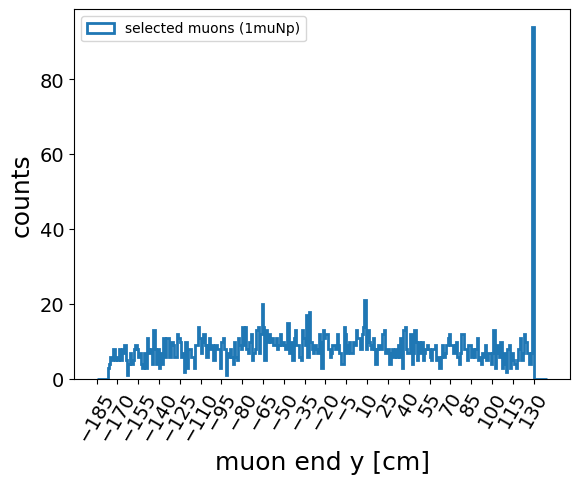

In [9]:
muon_end_y = []
for i,slice in enumerate(slices):
    true1muNp = False
    if slice['true_slice_classifications'] != 'bad_slice' and slice['true_slice_classifications'] != 'not_in_FV' and slice['true_slice_classifications'] != 'not_in_Active' and slice['true_slice_classifications'] != 'not_contained' and slice['true_slice_classifications'] != "cosmic" and slice['true_slice_classifications']!='reco_vertex_isNAN' and  slice['true_slice_classifications']!='true_vertex_isNAN' and slice['true_slice_classifications']!='not_numu' : 
        true = [int(char) for j,char in enumerate(slice['true_slice_classifications']) if j <= 4]
        if true[0] == 1 and true[1] >= 1 and true[2] == 0 and true[3] == 0 and true[4]==0: 
            true1muNp = True
    reco_1muNp = False
    if reco_class_newPID[i].startswith('bad_slice') == False :
        reco = [int(char) for char in reco_class_newPID[i]]
        if reco[0] == 1 and reco[1] >= 1 and reco[2] == 0 and reco[3] == 0 : reco_1muNp = True

    if reco_1muNp == True:
        selected_mu = info_selected_tracks_newPID[i]['muon']
        muon_end_y.append(selected_mu['end'][1])

muon_end_y = np.array(muon_end_y)
plt.hist(muon_end_y,bins=325,range=(-185,140),histtype='step',lw=2,label='selected muons (1muNp)')
plt.legend()
plt.xlabel('muon end y [cm]', fontsize=18)
plt.xticks(np.arange(-185,140,15), fontsize=14, rotation=60)
plt.ylabel('counts', fontsize=18)
plt.yticks(fontsize=14)
plt.savefig('muon_endy.pdf',format='pdf',bbox_inches='tight')

In [ ]:
correctly_classified_1muNp = 0

tot_reco1muNp=0
for i,slice in enumerate(slices):
    if reco_class_newPID[i].startswith('bad_slice')==True :  continue
    reco1muNp=False
    true1muNp=False
    reco = [int(char) for char in reco_class_newPID[i]]
    if reco[0] == 1 and reco[1] >= 1 and reco[2] == 0 and reco[3] == 0 : 
        reco1muNp=True
        tot_reco1muNp = tot_reco1muNp +1
    if slice['true_slice_classifications'] == 'bad_slice' or slice['true_slice_classifications'] == 'not_in_FV' or slice['true_slice_classifications'] == 'not_in_Active' or slice['true_slice_classifications'] == 'not_contained' or slice['true_slice_classifications'] == "cosmic" or slice['true_slice_classifications']=='reco_vertex_isNAN' or  slice['true_slice_classifications']=='true_vertex_isNAN' or slice['true_slice_classifications']=='not_numu' : continue
    true = [int(char) for j,char in enumerate(slice['true_slice_classifications']) if j <= 4]
    if true[0] == 1 and true[1] >= 1 and true[2] == 0 and true[3] == 0 and true[4]==0: true1muNp=True
    #print(reco_class_newPID[i], slice['true_slice_classifications'], reco1muNp==True and true1muNp==True)
    if reco1muNp==True and true1muNp==True : correctly_classified_1muNp = correctly_classified_1muNp +1

print('correctly classified 1muNp: ',correctly_classified_1muNp)
print('total selected 1muNp: ', tot_reco1muNp)
print('total true 1muNp: ', len(unique_pairs))

print('efficiency:', correctly_classified_1muNp/len(unique_pairs))
print('purity:',correctly_classified_1muNp/tot_reco1muNp)

In [29]:
for i,slice in enumerate(slices):
    if slice['true_slice_classifications'] == 'bad_slice' or slice['true_slice_classifications'] == 'not_in_FV' or slice['true_slice_classifications'] == 'not_in_Active' or slice['true_slice_classifications'] == 'not_contained' or slice['true_slice_classifications'] == "cosmic" or slice['true_slice_classifications']=='reco_vertex_isNAN' or  slice['true_slice_classifications']=='true_vertex_isNAN' or slice['true_slice_classifications']=='not_numu' : continue
    true = [int(char) for j,char in enumerate(slice['true_slice_classifications']) if j <= 4]
    if true[0] == 1 and true[1] >= 1 and true[2] == 0 and true[3] == 0 and true[4]==0: 
        true_class = '{}{}{}{}'.format(true[0],true[1],true[2],true[3]+true[4])
        maria_1muNp = False
        if reco_class[i].startswith('bad_slice') == False :
            reco = [int(char) for char in reco_class[i]]
            if reco[0] == 1 and reco[1] >= 1 and reco[2] == 0 and reco[3] == 0 : maria_1muNp = True
        nicola_1muNp = False
        if reco_class_newPID[i].startswith('bad_slice') == False :
            reco = [int(char) for char in reco_class_newPID[i]]
            if reco[0] == 1 and reco[1] >= 1 and reco[2] == 0 and reco[3] == 0 : nicola_1muNp = True

        if maria_1muNp==True and nicola_1muNp==False : 
            #print(slice['run'],slice['evt'],slice['slice_number'],slice['reco_vertex'][0],slice['reco_vertex'][1],slice['reco_vertex'][2])
            
            #choose which selection to watch
            info_selected_tracks = info_selected_tracks_newPID

            if info_selected_tracks[i]['muon']!=None : selected_muon = info_selected_tracks[i]['muon']
            selected_protons = info_selected_tracks[i]['protons']
            selected_pions = info_selected_tracks[i]['pions']
            print('***********',slice['run'], slice['evt'],'***********')

            print('slice classification: ', info_selected_tracks[i]['class'], '\n')
            print('true slice classification: ', true_class,'\n')

            if info_selected_tracks[i]['muon']!=None :
                print('MUON:\n','pdg: ',selected_muon['pdg'],'\n','length: ',selected_muon['length'],'\n','end: ',selected_muon['end'][0],selected_muon['end'][1],selected_muon['end'][2],'\n','pred proba: ',selected_muon['pred_proba'],'\n','depE: ',selected_muon['depE'],'\n','trackscore: ',selected_muon['trackscore'],'\n','chi2mu: ',selected_muon['chi2mu'],'\n','chi2pro: ',selected_muon['chi2pro'],'\n','rr(<25cm): ',[round(float(x),3) for x in selected_muon['rr']],'\n','dedx(<25cm): ',[round(float(x),3) for x in selected_muon['dedx']],'\n','likelihood ratios: ',[round(float(x),3) for x in selected_muon['lr']],'\n')

            for npro,pro in enumerate(selected_protons):
                print('PROTON{}:\n'.format(npro),'pdg: ',pro['pdg'],'\n','length: ',pro['length'],'\n','end: ',pro['end'][0],pro['end'][1],pro['end'][2],'\n','pred proba: ',pro['pred_proba'],'\n','depE: ',pro['depE'],'\n','trackscore: ',pro['trackscore'],'\n','chi2mu: ',pro['chi2mu'],'\n','chi2pro: ',pro['chi2pro'],'\n','Ekpro: ',pro['Ekpro'],'\n','Ekpi: ',pro['Ekpi'],'\n','rr(<25cm): ',[round(float(x),3) for x in pro['rr']],'\n','dedx(<25cm): ',[round(float(x),3) for x in pro['dedx']],'\n','likelihood ratios: ',[round(float(x),3) for x in pro['lr']],'\n')

            for npi,pi in enumerate(selected_pions):
                print('PION{}:\n'.format(npi),'pdg: ',pro['pdg'],'\n','length: ',pi['length'],'\n','end: ',pi['end'][0],pi['end'][1],pi['end'][2],'\n','pred proba: ',pi['pred_proba'],'\n','depE: ',pi['depE'],'\n','trackscore: ',pi['trackscore'],'\n','chi2mu: ',pi['chi2mu'],'\n','chi2pro: ',pi['chi2pro'],'\n','Ekpro: ',pi['Ekpro'],'\n','Ekpi: ',pi['Ekpi'],'\n','rr(<25cm): ',[round(float(x),3) for x in pi['rr']],'\n','dedx(<25cm): ',[round(float(x),3) for x in pi['dedx']],'\n','likelihood ratios: ',[round(float(x),3) for x in pi['lr']],'\n')


            #print(slice['run'],slice['evt'],slice['slice_number'])
        

*********** 9926 58032 ***********
slice classification:  0200 

true slice classification:  1100 

PROTON0:
 pdg:  2212 
 length:  33.28177261352539 
 end:  -267.7823181152344 -114.33132934570312 799.8463134765625 
 pred proba:  [0.00990675 0.01559005 0.85310691 0.09343635 0.00793673 0.02002322] 
 depE:  73.4400987625122 
 trackscore:  0.6705666780471802 
 chi2mu:  48.58821600162632 
 chi2pro:  2.5801604370602047 
 Ekpro:  233.6666677074668 
 Ekpi:  115.65680798712663 
 rr(<25cm):  [24.938, 24.644, 24.295, 23.949, 23.716, 23.356, 23.017, 22.616, 22.371, 21.99, 21.686, 21.415, 21.107, 20.706, 20.469, 20.208, 19.829, 19.507, 19.29, 18.961, 18.67, 18.344, 18.024, 17.729, 17.451, 16.982, 16.75, 16.471, 16.097, 15.818, 15.394, 15.039, 14.787, 14.44, 14.09, 13.771, 13.441, 13.195, 12.919, 12.548, 12.238, 11.984, 11.661, 11.33, 11.105, 10.835, 10.516, 10.257, 9.881, 9.658, 9.347, 9.062, 8.734, 8.445, 8.073, 7.749, 7.436, 7.107, 6.829, 6.585, 6.177, 5.903, 5.627, 5.277, 5.068, 4.667, 4.348, 4

In [ ]:
def get_best_cut(res):
    if res[0] == 0 :
        return 'muon not found'
    if res[0] == 1 and res[1] == 0 :
        return 'proton not found'
    if res[0] == 1 and res[1] >= 1 and res[2] > 0 :
        return 'pion found'
    if res[0] == 1 and res[1] >= 1 and res[2]== 0 and res[3] > 0 :
        return 'shower found'
    if res[0] == 1 and res[1] >= 1 and res[2]== 0 and res[3] == 0 :
        return '1muNp'

correct_standard = 0
correct_newPID = 0
correct_only_newPID = 0
correct_only_standard = 0
best_cut_standard = ''
best_cut_newPID = ''
newPID_best_cut_ONLYstandard = []
standard_best_cut_ONLYnewPID = []

for i,slice in enumerate(slices):
    reco1muNp_newPID=False
    reco1muNp = False
    true1muNp=False

    #true classification
    if slice['true_slice_classifications'] != 'bad_slice' and slice['true_slice_classifications'] != 'not_in_FV' and slice['true_slice_classifications'] != 'not_in_Active' and slice['true_slice_classifications'] != 'not_contained' and slice['true_slice_classifications'] != "cosmic" and slice['true_slice_classifications'] != 'reco_vertex_isNAN' and  slice['true_slice_classifications']!='true_vertex_isNAN' and slice['true_slice_classifications']!='not_numu' : 
        true = [int(char) for j,char in enumerate(slice['true_slice_classifications']) if j <= 4]
        if true[0] == 1 and true[1] >= 1 and true[2] == 0 and true[3] == 0 and true[4]==0: true1muNp=True
    
    #new PID classification
    if reco_class_newPID[i].startswith('bad_slice') == False :
        reco = [int(char) for char in reco_class_newPID[i]]
        best_cut_newPID = get_best_cut(reco)
        if get_best_cut(reco) == '1muNp' : reco1muNp_newPID=True

    #standard classification
    if reco_class[i].startswith('bad_slice') == False :
        reco = [int(char) for char in reco_class[i]]
        best_cut_standard = get_best_cut(reco)
        if get_best_cut(reco) == '1muNp' : reco1muNp=True


    if true1muNp==True and reco1muNp_newPID==True : correct_newPID = correct_newPID + 1
    if true1muNp==True and reco1muNp==True : correct_standard =  correct_standard + 1
    if true1muNp==True and reco1muNp_newPID==True and reco1muNp==False : 
        correct_only_newPID = correct_only_newPID + 1
        standard_best_cut_ONLYnewPID.append(best_cut_standard)
    if true1muNp==True and reco1muNp_newPID==False and reco1muNp==True : 
        correct_only_standard = correct_only_standard + 1
        newPID_best_cut_ONLYstandard.append(best_cut_newPID)

print('true1muNp slices selected (MARIA):',correct_standard)
print('true1muNp slices selected (newPID):', correct_newPID)
print('true1muNp slices selected (COMMON):', correct_standard-correct_only_standard)
print('true1muNp slices selected (ONLY nMARIA):', correct_only_standard)
print('true1muNp slices selected (ONLY newPID):', correct_only_newPID)

from collections import Counter
counts_newPID = Counter(newPID_best_cut_ONLYstandard)
total_events_newPID = len(newPID_best_cut_ONLYstandard)
relative_counts_newPID = {k: v/total_events_newPID for k, v in counts_newPID.items()}

counts_standard = Counter(standard_best_cut_ONLYnewPID)
total_events_standard = len(standard_best_cut_ONLYnewPID)
relative_counts_standard = {k: v/total_events_standard for k, v in counts_standard.items()}

bars1 = plt.bar(relative_counts_newPID.keys(), relative_counts_newPID.values() ,color='cornflowerblue',alpha=0.85, linewidth=3, label='newPID best cut (STANDARD selected only)')
bars2 = plt.bar(relative_counts_standard.keys(), relative_counts_standard.values() ,color='orange',alpha=0.85, linewidth=3, label='STANDARS best cut (newPID selected only)')
plt.bar_label(bars1, padding=3,fmt='%.2f',fontsize=14)
plt.bar_label(bars2, padding=3,fmt='%.2f',fontsize=14)
plt.ylim(0, max(relative_counts_standard.values())*1.15)
plt.legend(loc='upper right')
plt.xticks(rotation=60,fontsize=14)

## CUT FLOW EFFICIENCY

In [ ]:

unique_classes = []
nuEs = []

reco_class = np.array(reco_class)

count1muNpcorrect = 0
for r, e in unique_pairs:
#for r,e in int_evts: 
    #print('processing run: {} evt: {}'.format(int(r),int(e)))
    event_slice = slices[(slices['run']==int(r)) & (slices['evt']==int(e))]
    event_slice_reco = reco_class[(slices['run']==int(r)) & (slices['evt']==int(e))]
    best_classes = [] #FV_passed,barycenter_passed,containment_passed,has_a_muon,has_a_muon_and_at_lest_one_proton,has_no_pions,is_1muNp
    best_x = []
    best_y = []
    best_z = []
    nuE_thislice = []
    for i,slice in enumerate(event_slice):

        reco1muNp=False
        if event_slice_reco[i].startswith('bad_slice')==False:
            res = [int(char) for char in event_slice_reco[i]]
            if res[0] == 1 and res[1] >= 1 and res[2]== 0 and res[3] == 0 : reco1muNp = True

        true1muNp=False
        if slice['true_slice_classifications'] == 'bad_slice' or slice['true_slice_classifications'] == 'not_in_FV' or slice['true_slice_classifications'] == 'not_in_Active' or slice['true_slice_classifications'] == 'not_contained' or slice['true_slice_classifications'] == "cosmic" or slice['true_slice_classifications']=='reco_vertex_isNAN' or  slice['true_slice_classifications']=='true_vertex_isNAN' or slice['true_slice_classifications']=='not_numu' : continue
        true = [int(char) for j,char in enumerate(slice['true_slice_classifications']) if j <= 4]
        if true[0] == 1 and true[1] >= 1 and true[2] == 0 and true[3] == 0 and true[4]==0: true1muNp=True

        if true1muNp == False : continue
        #showers = find_shower_full_vectorized(slice)
        #for track in range(len(slice['tracks.reco.length'])):
        #    if track in showers :
        #        print('    ',slice['tracks.reco.length'][track], slice['tracks.reco.chi2_as_pro'][track], slice['tracks.reco.trackscore'][track])

        best_class = - 1
        if slice['isinFV'] == False : 
            best_class = 2
            best_classes.append(best_class)
            best_x.append(slice['reco_vertex'][0])
            best_y.append(slice['reco_vertex'][1])
            best_z.append(slice['reco_vertex'][2])
            nuE_thislice.append(slice['true_neutrino_energy'])
            continue

        barycenter_passed = True
        delta = np.abs(slice['barycenter']-slice['bar_charge'])
        if slice['barycenter_x']*slice['reco_vertex'][0] <= 0 : barycenter_passed = False
        if slice['barycenter'] <= -10000 : barycenter_passed = False
        if delta <= 0 or delta >= 100 : barycenter_passed = False
        if barycenter_passed == False : 
            best_class = 3
            best_x.append(slice['reco_vertex'][0])
            best_y.append(slice['reco_vertex'][1])
            best_z.append(slice['reco_vertex'][2])
            nuE_thislice.append(slice['true_neutrino_energy'])
            best_classes.append(best_class)
            continue

        if slice['all_tracks_contained']==False : 
            best_class = 4
            best_x.append(slice['reco_vertex'][0])
            best_y.append(slice['reco_vertex'][1])
            best_z.append(slice['reco_vertex'][2])
            nuE_thislice.append(slice['true_neutrino_energy'])
            best_classes.append(best_class)
            continue

        if event_slice_reco[i].startswith('bad_slice')==False:
            res = [int(char) for char in event_slice_reco[i]]
            if res[0] == 0 :
                best_class = 6
                best_x.append(slice['reco_vertex'][0])
                best_y.append(slice['reco_vertex'][1])
                best_z.append(slice['reco_vertex'][2])
                nuE_thislice.append(slice['true_neutrino_energy'])
                best_classes.append(best_class)
                continue
            if res[0] == 1 and res[1] == 0 :
                best_class = 7
                best_x.append(slice['reco_vertex'][0])
                best_y.append(slice['reco_vertex'][1])
                best_z.append(slice['reco_vertex'][2])
                nuE_thislice.append(slice['true_neutrino_energy'])
                best_classes.append(best_class)
                continue
            if res[0] == 1 and res[1] >= 1 and res[2] > 0 :
                best_class = 8
                best_x.append(slice['reco_vertex'][0])
                best_y.append(slice['reco_vertex'][1])
                best_z.append(slice['reco_vertex'][2])
                nuE_thislice.append(slice['true_neutrino_energy'])
                best_classes.append(best_class)
                continue
            if res[0] == 1 and res[1] >= 1 and res[2]== 0 and res[3] > 0 :
                best_class = 9
                best_x.append(slice['reco_vertex'][0])
                best_y.append(slice['reco_vertex'][1])
                best_z.append(slice['reco_vertex'][2])
                nuE_thislice.append(slice['true_neutrino_energy'])
                best_classes.append(best_class)
                continue
            if res[0] == 1 and res[1] >= 1 and res[2]== 0 and res[3] == 0 :
                best_class = 10
                best_x.append(slice['reco_vertex'][0])
                best_y.append(slice['reco_vertex'][1])
                best_z.append(slice['reco_vertex'][2])
                nuE_thislice.append(slice['true_neutrino_energy'])
                best_classes.append(best_class)

        if reco1muNp == True and true1muNp == True : count1muNpcorrect = count1muNpcorrect +1
    
        #print(slice['run'],slice['evt'],slice['reco_vertex'],best_class)
    if len(best_classes) > 0 : 
        unique_classes.append(max(best_classes))
        nuEs.append(nuE_thislice[best_classes.index(max(best_classes))])
        #print(int(r),int(e),'{:.3f}'.format(best_x[best_classes.index(max(best_classes))]), '{:.3f}'.format(best_y[best_classes.index(max(best_classes))]), '{:.3f}'.format(best_z[best_classes.index(max(best_classes))]), max(best_classes))
    else : print('NEUTRINO SENZA SLICE')

print(len(unique_classes), len(nuEs))
nuE_passed_FV = []
nuE_passed_barycenter = []
nuE_passed_containment = []
nuE_muon = []
nuE_proton = []
nuE_not_pion = []
nuE_is_1muNp = []
for i,cls in enumerate(unique_classes):
    if cls > 2 : nuE_passed_FV.append(nuEs[i]) 
    if cls > 3 : nuE_passed_barycenter.append(nuEs[i])
    if cls > 4 : nuE_passed_containment.append(nuEs[i])
    if cls > 6 : nuE_muon.append(nuEs[i])
    if cls > 7 : nuE_proton.append(nuEs[i])
    if cls > 8 : nuE_not_pion.append(nuEs[i])
    if cls > 9 : nuE_is_1muNp.append(nuEs[i])
print('passed FV: ',len(nuE_passed_FV),'efficiency FV cut: ',len(nuE_passed_FV)/len(nuEs))
print('passed barycenter: ',len(nuE_passed_barycenter),'efficiency barycenter cut: ',len(nuE_passed_barycenter)/len(nuEs))
print('passed containment: ',len(nuE_passed_containment),'efficiency containment cut: ',len(nuE_passed_containment)/len(nuEs))
print('muon found: ',len(nuE_muon),'efficiency muon found cut: ',len(nuE_muon)/len(nuEs))
print('proton found: ',len(nuE_proton),'efficiency proton found cut: ',len(nuE_proton)/len(nuEs))
print('not pion found: ',len(nuE_not_pion),'efficiency not pion found cut: ',len(nuE_not_pion)/len(nuEs))
print('1muNp: ',len(nuE_is_1muNp),'efficiency 1muNp: ',len(nuE_is_1muNp)/len(nuEs))
print(count1muNpcorrect)

In [ ]:

unique_classes_newPID = []
nuEs_newPID = []

reco_class_newPID = np.array(reco_class_newPID)

#interesting_runs = [9583,9342,9534,9944,9976,9926,9359,10085,9344,10065,9389,9735,9329,9342,9914,9337,9386,9409,9744,9807]
#interesting_evts = [8744,104641,23751,1395,45400,15618,15352,44128,34812,16661,17546,2178,24293,16189,65580,5408,4685,20228,3388,7351]
#int_evts = np.column_stack((interesting_runs, interesting_evts))
for r, e in unique_pairs:
#for r,e in int_evts: 
    #print('processing run: {} evt: {}'.format(int(r),int(e)))
    event_slice = slices[(slices['run']==int(r)) & (slices['evt']==int(e))]
    event_slice_reco = reco_class_newPID[(slices['run']==int(r)) & (slices['evt']==int(e))]
    best_classes = [] #FV_passed,barycenter_passed,containment_passed,has_a_muon,has_a_muon_and_at_lest_one_proton,has_no_pions,is_1muNp
    best_x = []
    best_y = []
    best_z = []
    nuE_thislice = []
    for i,slice in enumerate(event_slice):

        true1muNp=False
        if slice['true_slice_classifications'] == 'bad_slice' or slice['true_slice_classifications'] == 'not_in_FV' or slice['true_slice_classifications'] == 'not_in_Active' or slice['true_slice_classifications'] == 'not_contained' or slice['true_slice_classifications'] == "cosmic" or slice['true_slice_classifications']=='reco_vertex_isNAN' or  slice['true_slice_classifications']=='true_vertex_isNAN' or slice['true_slice_classifications']=='not_numu' : continue
        true = [int(char) for j,char in enumerate(slice['true_slice_classifications']) if j <= 4]
        if true[0] == 1 and true[1] >= 1 and true[2] == 0 and true[3] == 0 and true[4]==0: true1muNp=True

        if true1muNp == False : continue
        #showers = find_shower_full_vectorized(slice)
        #for track in range(len(slice['tracks.reco.length'])):
        #    if track in showers :
        #        print('    ',slice['tracks.reco.length'][track], slice['tracks.reco.chi2_as_pro'][track], slice['tracks.reco.trackscore'][track])

        best_class = - 1
        if slice['isinFV'] == False : 
            best_class = 2
            best_classes.append(best_class)
            best_x.append(slice['reco_vertex'][0])
            best_y.append(slice['reco_vertex'][1])
            best_z.append(slice['reco_vertex'][2])
            nuE_thislice.append(slice['true_neutrino_energy'])
            continue


        barycenter_passed = True
        delta = np.abs(slice['barycenter']-slice['bar_charge'])
        if slice['barycenter_x']*slice['reco_vertex'][0] <= 0 : barycenter_passed = False
        if slice['barycenter'] <= -10000 : barycenter_passed = False
        if delta <= 0 or delta >= 100 : barycenter_passed = False
        if barycenter_passed == False : 
            best_class = 3
            best_classes.append(best_class)
            best_x.append(slice['reco_vertex'][0])
            best_y.append(slice['reco_vertex'][1])
            best_z.append(slice['reco_vertex'][2])
            nuE_thislice.append(slice['true_neutrino_energy'])
            continue

        if slice['all_tracks_contained']==False : 
            best_class = 4
            best_classes.append(best_class)
            best_x.append(slice['reco_vertex'][0])
            best_y.append(slice['reco_vertex'][1])
            best_z.append(slice['reco_vertex'][2])
            nuE_thislice.append(slice['true_neutrino_energy'])
            continue

        if event_slice_reco[i].startswith('bad_slice')==False:
            res = [int(char) for char in event_slice_reco[i]]
            if res[0] == 0 :
                best_class = 6
                best_classes.append(best_class)
                best_x.append(slice['reco_vertex'][0])
                best_y.append(slice['reco_vertex'][1])
                best_z.append(slice['reco_vertex'][2])
                nuE_thislice.append(slice['true_neutrino_energy'])
                continue
            if res[0] == 1 and res[1] == 0 :
                best_class = 7
                best_classes.append(best_class)
                best_x.append(slice['reco_vertex'][0])
                best_y.append(slice['reco_vertex'][1])
                best_z.append(slice['reco_vertex'][2])
                nuE_thislice.append(slice['true_neutrino_energy'])
                continue
            if res[0] == 1 and res[1] >= 1 and res[2] > 0 :
                best_class = 8
                best_classes.append(best_class)
                best_x.append(slice['reco_vertex'][0])
                best_y.append(slice['reco_vertex'][1])
                best_z.append(slice['reco_vertex'][2])
                nuE_thislice.append(slice['true_neutrino_energy'])
                continue
            if res[0] == 1 and res[1] >= 1 and res[2]== 0 and res[3] > 0 :
                best_class = 9
                best_classes.append(best_class)
                best_x.append(slice['reco_vertex'][0])
                best_y.append(slice['reco_vertex'][1])
                best_z.append(slice['reco_vertex'][2])
                nuE_thislice.append(slice['true_neutrino_energy'])
                continue
            if res[0] == 1 and res[1] >= 1 and res[2]== 0 and res[3] == 0 :
                best_class = 10
                best_classes.append(best_class)
                best_x.append(slice['reco_vertex'][0])
                best_y.append(slice['reco_vertex'][1])
                best_z.append(slice['reco_vertex'][2])
                nuE_thislice.append(slice['true_neutrino_energy'])
                continue
        
        best_classes.append(best_class)
        best_x.append(slice['reco_vertex'][0])
        best_y.append(slice['reco_vertex'][1])
        best_z.append(slice['reco_vertex'][2])
        nuE_thislice.append(slice['true_neutrino_energy'])


        #print(slice['run'],slice['evt'],slice['reco_vertex'],best_class)
    if len(best_classes) > 0 : 
        unique_classes_newPID.append(max(best_classes))
        nuEs_newPID.append(nuE_thislice[best_classes.index(max(best_classes))])
        #print(int(r),int(e),'{:.3f}'.format(best_x[best_classes.index(max(best_classes))]), '{:.3f}'.format(best_y[best_classes.index(max(best_classes))]), '{:.3f}'.format(best_z[best_classes.index(max(best_classes))]), max(best_classes))
    #else : print('NEUTRINO SENZA SLICE')

print(len(unique_classes_newPID), len(nuEs_newPID))
nuE_passed_FV_newPID = []
nuE_passed_barycenter_newPID = []
nuE_passed_containment_newPID = []
nuE_muon_newPID = []
nuE_proton_newPID = []
nuE_not_pion_newPID = []
nuE_is_1muNp_newPID = []
for i,cls in enumerate(unique_classes_newPID):
    if cls > 2 : nuE_passed_FV_newPID.append(nuEs_newPID[i]) 
    if cls > 3 : nuE_passed_barycenter_newPID.append(nuEs_newPID[i])
    if cls > 4 : nuE_passed_containment_newPID.append(nuEs_newPID[i])
    if cls > 6 : nuE_muon_newPID.append(nuEs_newPID[i])
    if cls > 7 : nuE_proton_newPID.append(nuEs_newPID[i])
    if cls > 8 : nuE_not_pion_newPID.append(nuEs_newPID[i])
    if cls > 9 : nuE_is_1muNp_newPID.append(nuEs_newPID[i])
print('passed FV: ',len(nuE_passed_FV_newPID),'efficiency FV cut: ',len(nuE_passed_FV_newPID)/len(nuEs_newPID))
print('passed barycenter: ',len(nuE_passed_barycenter_newPID),'efficiency barycenter cut: ',len(nuE_passed_barycenter_newPID)/len(nuEs_newPID))
print('passed containment: ',len(nuE_passed_containment_newPID),'efficiency containment cut: ',len(nuE_passed_containment_newPID)/len(nuEs_newPID))
print('muon found: ',len(nuE_muon_newPID),'efficiency muon found cut: ',len(nuE_muon_newPID)/len(nuEs_newPID))
print('proton found: ',len(nuE_proton_newPID),'efficiency proton found cut: ',len(nuE_proton_newPID)/len(nuEs_newPID))
print('not pion found: ',len(nuE_not_pion_newPID),'efficiency not pion found cut: ',len(nuE_not_pion_newPID)/len(nuEs_newPID))
print('1muNp: ',len(nuE_is_1muNp_newPID),'efficiency 1muNp: ',len(nuE_is_1muNp_newPID)/len(nuEs_newPID))

In [ ]:
#true_nu_interaction = np.loadtxt("dumpNuE_fin_uniq.txt")
true_nuE_all = nuEs
print(len(true_nuE_all))

bin_edges = np.array([0.3, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0, 1.25, 1.5, 2.0, 2.5])
counts_all, _ = np.histogram(true_nuE_all, bins=bin_edges)
    
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

selections = {
    "FV": {'data':nuE_passed_FV,'color':'blue','ls':'solid','alpha':1},
    "Barycenter + PMT/CRT": {'data':nuE_passed_barycenter, 'color':'orange','ls':'solid','alpha':1},
    "Containment": {'data':nuE_passed_containment, 'color':'deepskyblue','ls':'solid','alpha':1},
    "Muon ID": {'data':nuE_muon,'color':'red','ls':'solid','alpha':1},
    "Proton ID": {'data':nuE_proton,'color':'darkviolet','ls':'solid','alpha':1},
    "No pion": {'data':nuE_not_pion,'color':'gold','ls':'solid','alpha':1},
    "1μNp": {'data':nuE_is_1muNp,'color':'darkgreen','ls':'solid','alpha':1},
    "Muon ID (new PID)": {'data':nuE_muon_newPID,'color':'lightcoral','ls':'dashed','alpha':0.7},
    "Proton ID (new PID)": {'data':nuE_proton_newPID,'color':'orchid','ls':'dashed','alpha':0.7},
    "No pion (new PID)": {'data':nuE_not_pion_newPID,'color':'gold','ls':'dashed','alpha':0.65},
    "1μNp (new PID)": {'data':nuE_is_1muNp_newPID,'color':'green','ls':'dashed','alpha':0.7}
}

colors = plt.cm.tab20.colors
for i, (label, info) in enumerate(selections.items()):

    counts_sel, _ = np.histogram(info['data'], bins=bin_edges)

    ratio = np.zeros_like(counts_all, dtype=float)
    mask = counts_all > 0
    ratio[mask] = counts_sel[mask] / counts_all[mask]
    #print("Max ratio:", np.max(ratio))
    #print("Min ratio:", np.min(ratio))

    # Binomial error (safe)
    errors = np.zeros_like(ratio)
    errors[mask] = np.sqrt(ratio[mask] * (1 - ratio[mask]) / counts_all[mask])

    # Plot step
    plt.stairs(ratio, bin_edges, color=info['color'], linewidth=2,ls=info['ls'], alpha=info['alpha'],label=label)

    # Plot error bars
    plt.errorbar(bin_centers, ratio, yerr=errors, fmt='o', markersize=3, color=info['color'], alpha=info['alpha'])

plt.legend(fontsize=8,ncol=2)
plt.xlabel('true neutrino energy [GeV]', fontsize=18)
plt.xticks(fontsize=18)
plt.ylabel('efficiency', fontsize='18')
plt.yticks(fontsize=18)
plt.savefig('cutflow_true_neutrino_energy_ratio_uniq.pdf',format='pdf',bbox_inches='tight')
plt.close()


## PLOT

In [ ]:
def find_candidate_muon_true(slices):
    lengths = slices['tracks.reco.length']

    mask = (
        #(~slices['is_clear_cosmic']) & # INCLUDED IN THE SLICE SELECTION
        (slices['tracks.reco.trackscore'] >= 0.5) &
        (slices['tracks.reco.start_distance_from_reco_vertex'] < 10) &
        (lengths > 50) &
        ( (slices['tracks.truth.pdg']==13) | (slices['tracks.truth.pdg']==-13) ) &
        #endy &
        (slices['tracks.reco.all_in_1_tpc']) &
        (slices['tracks.reco.is_primary']) &
        #(slices['tracks.reco.is_start_contained']) 
        (slices['tracks.reco.is_end_contained']) #INCLUDED IN THE SLICE SELECTION
    )

    valid = ak.any(mask, axis=1)

    muon_idx = ak.argmax(ak.where(mask, lengths, -1), axis=1)

    muon_idx = ak.where(valid, muon_idx, -1)
    muon_idx = ak.mask(muon_idx, muon_idx != -1)
    return muon_idx

muon_candidates = find_candidate_muon_true(slices)

mu_probability_as_mu = []
mu_probability_as_mu_int = []
mu_probability_as_pi = []
mu_probability_as_pi_int = []

hits_number_missed_mu = []
wrong_class_misssed_mu = []
rr_wrong_mu = []
dedx_wrong_mu = []

hits_number_mu = []
class_mu = []
rr_good_mu = []
dedx_good_mu = []
for i,slice in enumerate(slices):
    muon_idx = muon_candidates[i]
    if muon_idx == None : continue
    #print(muon_idx)
    features = ak.to_list(slice['tracks.reco.likelihood_ratios'][muon_idx]) + [ slice['tracks.reco.deposited_energy'][muon_idx] ]
    predicted_class = gbdt_model.predict([features])[0]
    predicted_proba = gbdt_model.predict_proba([features])
    #print(predicted_class, predicted_class[0])
    mu_probability_as_mu.append(predicted_proba[0])
    mu_probability_as_mu_int.append(predicted_proba[1])
    mu_probability_as_pi.append(predicted_proba[4])
    mu_probability_as_pi_int.append(predicted_proba[5])
    
    if predicted_class in [0,1]:
        hits_number_mu.append(np.sum((slice['tracks.reco.rr'][muon_idx]>1) & (slice['tracks.reco.rr'][muon_idx]>1)))
        class_mu.append(predicted_class)
        rr_good_mu.extend(ak.to_list(slice['tracks.reco.rr'][muon_idx]))
        dedx_good_mu.extend(ak.to_list(slice['tracks.reco.dedx'][muon_idx]))
    if predicted_class not in [0,1]:
        hits_number_missed_mu.append(np.sum((slice['tracks.reco.rr'][muon_idx]>1) & (slice['tracks.reco.rr'][muon_idx]>1)))
        wrong_class_misssed_mu.append(predicted_class)
        rr_wrong_mu.extend(ak.to_list(slice['tracks.reco.rr'][muon_idx]))
        dedx_wrong_mu.extend(ak.to_list(slice['tracks.reco.dedx'][muon_idx]))

In [ ]:
plt.hist(np.array(mu_probability_as_mu),bins=100,range=(0,1),histtype='step',lw=2,label=r'prob as $\mu$')
plt.hist(np.array(mu_probability_as_mu_int), bins=100,range=(0,1),histtype='step',lw=2,label=r'prob as int. $\mu$')
plt.hist(np.array(mu_probability_as_pi), bins=100, range=(0,1), histtype='step', lw=2, label=r'prob as $\pi$')
plt.hist(np.array(mu_probability_as_pi_int), bins=100, range=(0,1), histtype='step', lw=2, label=r'prob as int. $\pi$')
plt.xlabel('predicted probability')
plt.show()

In [ ]:
from matplotlib.colors import LogNorm
plt.hist(np.array(hits_number_missed_mu),bins=100, range=(0,200), histtype='step', lw=2, label='wrong class tracks')
plt.hist(np.array(hits_number_mu),bins=100, range=(0,200), histtype='step', lw=2, label='correct class tracks')
plt.legend()
plt.xlabel('number of hits in COLL plane')
plt.show()
plt.hist(np.array(wrong_class_misssed_mu),bins=6,range=(0,6),histtype='step',lw=2, label='wrong class tracks')
plt.hist(np.array(class_mu),bins=6,range=(0,6),histtype='step',lw=2, label='correct class tracks')
plt.legend()
plt.xlabel('muon predicted class')
plt.show()
plt.hist2d(np.array(rr_wrong_mu), np.array(dedx_wrong_mu), bins=(500,300), range=[(0,25),(0,30)], cmap='viridis', norm=LogNorm())
cbar=plt.colorbar()
plt.show()
plt.hist2d(np.array(rr_good_mu), np.array(dedx_good_mu), bins=(500,300), range=[(0,25),(0,30)], cmap='viridis', norm=LogNorm())
cbar=plt.colorbar()
plt.show()

In [ ]:
muon_candidates = find_candidate_muon_full_vectorized_BDT_new(slices)
pfps = find_pfp_full_vectorized(slices)

true_muons_classes = []
true_pion_classes = []
true_proton_classes = []
for i,slice in enumerate(slices):
    muon_idx = muon_candidates[i] 
    pfps_idxs = pfps[i]
    if(len(muon_idx)==0 and len(pfps_idxs)==0) : continue
    else:
        found_mu = -1
        #is the muon candidate a muon ?
        if(len(muon_idx)==0) : continue
        else : 
            mu_with_prob = []
            for mu in muon_idx:
                features = ak.to_list(slice['tracks.reco.likelihood_ratios'][mu]) + [ slice['tracks.reco.deposited_energy'][mu] ]
                predicted_class = gbdt_model.predict([features])[0] 
                if predicted_class == 2 or predicted_class == 3 : continue
                predicted_proba = gbdt_model.predict_proba([features])[0]
                if predicted_proba[0] > predicted_proba[1] : mu_with_prob.append((mu, predicted_proba[0]))
                else : mu_with_prob.append((mu, predicted_proba[1])) 
            if len(mu_with_prob) > 0 : 
                found_mu = max(mu_with_prob, key=lambda x: x[1])[0]
                true_muons_classes.append(slice['tracks.truth.true_class'][found_mu])
        #check for protons and pions 
        if len(pfps_idxs)==0 : continue
        else :
            classified_indeces=[]
            if found_mu != -1 : classified_indeces.append(found_mu)
            for p in pfps_idxs:
                if p in classified_indeces : continue
                features = ak.to_list(slice['tracks.reco.likelihood_ratios'][p]) + [ slice['tracks.reco.deposited_energy'][p] ]
                predicted_class = gbdt_model.predict([features])[0]
                if (predicted_class==4 or predicted_class==5 or predicted_class==0 or predicted_class==1) and slice['tracks.reco.energy_deposited_as_pi'][p]>=25 and slice['tracks.reco.trackscore'][p]>=0.5 : 
                    true_pion_classes.append(slice['tracks.truth.true_class'][p])
                    classified_indeces.append(p)
                elif (predicted_class==2 or predicted_class==3) and slice['tracks.reco.energy_deposited_as_pro'][p]>=50 : 
                    #print(slice['tracks.truth.true_class'][p])
                    true_proton_classes.append(slice['tracks.truth.true_class'][p])
                    classified_indeces.append(p)


In [ ]:
plt.hist(np.array(true_muons_classes),bins=6,range=(0,6),histtype='step',lw=2)
plt.show()
plt.close()
plt.hist(np.array(true_proton_classes),bins=6,range=(0,6),histtype='step',lw=2)
plt.show()
plt.close()
plt.hist(np.array(true_pion_classes),bins=6,range=(0,6),histtype='step',lw=2)
plt.show()
plt.close()

In [ ]:
from collections import Counter
true_slice_class=[]
for i,slice in enumerate(slices):
    if reco_class_newPID[i].startswith('bad_slice')==True :  continue
    reco = [int(char) for char in reco_class_newPID[i]]
    if reco[0] == 1 and reco[1] >= 1 and reco[2] == 0 and reco[3] == 0 : 
        if slice['true_slice_classifications'] == 'not_in_FV' or slice['true_slice_classifications'] == 'not_in_Active' or slice['true_slice_classifications'] == 'not_contained' or slice['true_slice_classifications'] == "cosmic" or slice['true_slice_classifications']=='reco_vertex_isNAN' or  slice['true_slice_classifications']=='true_vertex_isNAN' or slice['true_slice_classifications']=='not_numu' :
            returned_srting = 'OTHER'
        else :
            true = [int(char) for j,char in enumerate(slice['true_slice_classifications']) if j <= 4]
            nprotons = '0'
            npions = '0'
            nshowers = '0'
            if true[1] == 0 : nprotons = '0' 
            else : nprotons = 'N'
            if true[2] == 0 : npions = '0' 
            else : npions = 'M'
            if true[3] + true[4] == 0 : nshowers = '0' 
            else : nshowers = 'G'

            returned_srting = r'{}{}{}{}'.format(str(true[0]),nprotons,npions,nshowers)
        
        if returned_srting == '1000' : print(slice['run'],slice['evt'],slice['reco_vertex'])
        true_slice_class.append(returned_srting)

custom_order = ['1N00', '1NM0', '1N0G', '10M0', '10MG', '100G', '1NMG', '1000', '0NM0', '0N0G', '0NMG', '0N00', '00M0', '00MG', '000G', '0000', 'OTHER']

counts = Counter(true_slice_class)
total_events = sum(counts.values())
relative_counts = {k: v/total_events*100 for k, v in counts.items()}

couts_in_order = [relative_counts[k] for k in custom_order]

bars = plt.bar(custom_order, couts_in_order,color='cornflowerblue',alpha=0.85)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,  # centro della barra
        height,                           # altezza della barra
        f'{height:.1f}',                 # testo in percentuale
        ha='center', va='bottom',         # allineamento
        rotation=60,                       # rotazione etichetta
        fontsize = 14
    )

plt.xticks(rotation=60,fontsize=14)
#plt.bar_label(bars, padding=3,fmt='%.1f',fontsize=14)
plt.xlabel(r'#$\mu$ #p #$\pi$ #$\gamma$', fontsize=18)
plt.ylabel('% of each category',fontsize=18)
plt.ylim(0, max(relative_counts.values())*1.15)
plt.savefig('purity_newPID_new.pdf',format='pdf',bbox_inches='tight')

### Plot efficiency true Neutrino Energy

In [ ]:
true_nu_interaction = np.loadtxt("dumpNuE_fin.txt")
true_nuE_all = true_nu_interaction[:,2]
print(len(true_nuE_all))
true_nuE_selected = []
true_nuE_selected_newPID = []

#bin_edges = [0.3,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.80,0.85,0.9,0.95,1.0,1.25,1.5,2.0,3.0]
bin_edges = np.array([0.3, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0, 1.25, 1.5, 2.0, 2.5])

for i,slice in enumerate(slices):
    if slice['true_slice_classifications'] == 'bad_slice' or slice['true_slice_classifications'] == 'not_in_FV' or slice['true_slice_classifications'] == 'not_in_Active' or slice['true_slice_classifications'] == 'not_contained' or slice['true_slice_classifications'] == "cosmic" or slice['true_slice_classifications']=='reco_vertex_isNAN' or  slice['true_slice_classifications']=='true_vertex_isNAN' or slice['true_slice_classifications']=='not_numu' : continue
    if reco_class[i] != 'bad_slice' : 
        true1muNp=False
        reco1muNp=False
        reco = [int(char) for char in reco_class[i]]
        true = [int(char) for j,char in enumerate(slice['true_slice_classifications']) if j <= 4]
        if reco[0] == 1 and reco[1] >= 1 and reco[2] == 0 and reco[3] == 0 : reco1muNp=True
        if true[0] == 1 and true[1] >= 1 and true[2] == 0 and true[3] == 0 and true[4]==0: true1muNp=True
        #print(reco_class[i], slice['true_slice_classifications'], reco1muNp==True and true1muNp==True)
        if reco1muNp==True and true1muNp==True : 
            true_nuE_selected.append(slice['true_neutrino_energy'])
    if reco_class_newPID[i] != 'bad_slice' : 
        true1muNp=False
        reco1muNp=False
        reco = [int(char) for char in reco_class_newPID[i]]
        true = [int(char) for j,char in enumerate(slice['true_slice_classifications']) if j <= 4]
        if reco[0] == 1 and reco[1] >= 1 and reco[2] == 0 and reco[3] == 0 : reco1muNp=True
        if true[0] == 1 and true[1] >= 1 and true[2] == 0 and true[3] == 0 and true[4]==0: true1muNp=True
        #print(reco_class_newPID[i], slice['true_slice_classifications'], reco1muNp==True and true1muNp==True)
        if reco1muNp==True and true1muNp==True : 
            true_nuE_selected_newPID.append(slice['true_neutrino_energy'])   
    

counts_all,edges_all,_ = plt.hist(true_nuE_all,bins=bin_edges,range=(0,3),histtype='step',color='cornflowerblue',label='All 1muNp interaction',alpha=0.7,lw=2)
counts_selected,edges_selected,_ = plt.hist(true_nuE_selected,bins=bin_edges,range=(0,3),histtype='step',color='orange',label='Selected 1muNp',alpha=0.7,lw=2)
counts_selected_newPID,edges_selected_newPID,_ = plt.hist(true_nuE_selected_newPID,bins=bin_edges,range=(0,3),histtype='step',color='red',label='Selected 1muNp new PID',alpha=0.7,lw=2)
plt.legend(fontsize=12)
plt.xlabel('true neutrino energy [GeV]', fontsize=18)
plt.xticks(fontsize=18)
plt.ylabel('counts', fontsize='18')
plt.yticks(fontsize=18)
plt.savefig('true_neutrino_energy.pdf',format='pdf',bbox_inches='tight')
plt.close()

ratio = np.divide(
    counts_selected,
    counts_all,
    out=np.zeros_like(counts_all, dtype=float),
    where=counts_all != 0
)

ratio_new_PID = np.divide(
    counts_selected_newPID,
    counts_all,
    out=np.zeros_like(counts_all, dtype=float),
    where=counts_all != 0
)

errors = np.sqrt(ratio*(1-ratio)/counts_all)
errors_newPID = np.sqrt(ratio_new_PID*(1-ratio_new_PID)/counts_all)
bin_centers = 0.5 * (edges_all[:-1] + edges_all[1:])

plt.hist( bin_centers, bins=bin_edges, weights=ratio, histtype='step', color='orange', lw=2, label='chi2 PID')
plt.hist( bin_centers, bins=bin_edges, weights=ratio_new_PID, histtype='step', color='red', lw=2, label='new PID')
plt.errorbar(bin_centers,ratio,errors,fmt='o',markersize=4,color='orange')
plt.errorbar(bin_centers,ratio_new_PID,errors,fmt='o',markersize=4,color='red')
plt.legend(fontsize=12)
plt.xlabel('true neutrino energy [GeV]', fontsize=18)
plt.xticks(fontsize=18)
plt.ylabel('counts all true int. / counts selcted int.', fontsize='18')
plt.yticks(fontsize=18)
plt.savefig('true_neutrino_energy_ratio.pdf',format='pdf',bbox_inches='tight')
plt.close()

print(counts_all, '\n')
print(counts_selected, '\n')
print(counts_selected_newPID, '\n')
print(ratio,errors,'\n')
print(ratio_new_PID,errors_newPID,'\n')